---
title: "DEL - Mini Challenge"
author: "Luca Manna"
date: "2026-04-17"
format:
  html:
    toc: true
    number-sections: true
    code-fold: show
    embed-resources: true
lang: de
---

# Mini-Challenge DEL: Hyperparameter Tuning und Model Evaluation

**Task:** Bildklassifikation mit dem Intel Image Classification Dataset (6 Klassen: buildings, forest, glacier, mountain, sea, street).

**Stage 1:** Basismodell mit CNN, LR- und Batch-Size-Tuning, Cross-Validation.

## Imports und Setup

Alle benötigten Bibliotheken: PyTorch, torchvision, HuggingFace datasets, scikit-learn, W&B.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset

# HuggingFace datasets
from datasets import load_dataset, load_from_disk

# Scikit-learn (metrics, cross-validation)
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Experiment tracking
import wandb

# Utilities
import os
import time
from pathlib import Path

# GLobal variables
RANDOM_SEED = 42
DATA_DIR = Path("../data/intel-image-classification")

# Set random seeds for reproducibility
torch.manual_seed(RANDOM_SEED)

### Daten laden

Intel Image Classification Dataset von HuggingFace laden (bzw. von Disk falls bereits heruntergeladen).

In [2]:
if DATA_DIR.exists():
    print("Loading dataset from disk...")
    dataset = load_from_disk(str(DATA_DIR))
else:
    print("Downloading dataset from HuggingFace...")
    dataset = load_dataset("sfarrukhm/intel-image-classification")
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    dataset.save_to_disk(str(DATA_DIR))
    print(f"Dataset saved to {DATA_DIR}")

print(dataset)
print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Test samples:  {len(dataset['test'])}")
print(f"\nFeatures: {dataset['train'].features}")
print(f"Labels:   {dataset['train'].features['label'].names}")

Loading dataset from disk...
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 14034
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 3000
    })
})

Train samples: 14034
Test samples:  3000

Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'])}
Labels:   ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Explorative Analyse

   Klasse  Train  Test  Train %  Test %
buildings   2191   437     15.6    14.6
   forest   2271   474     16.2    15.8
  glacier   2404   553     17.1    18.4
 mountain   2512   525     17.9    17.5
      sea   2274   510     16.2    17.0
   street   2382   501     17.0    16.7


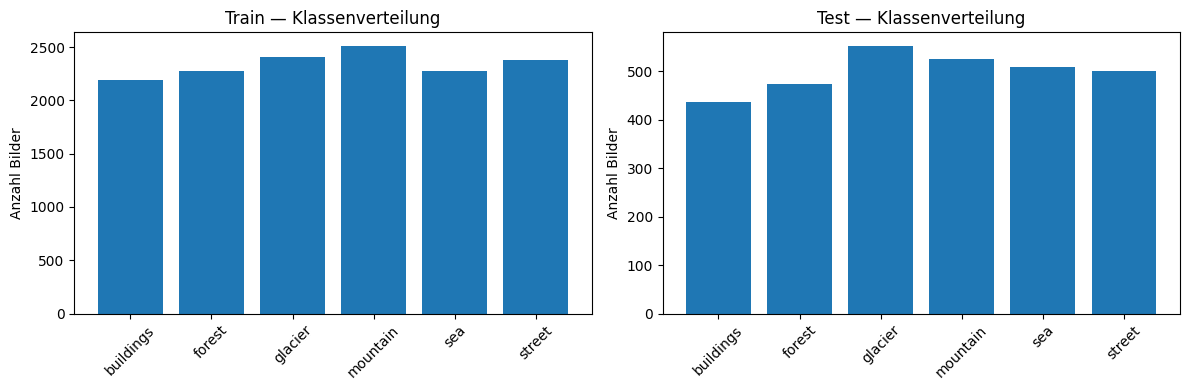

In [3]:
# Klassenverteilung im Train- und Test-Split
label_names = dataset["train"].features["label"].names
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts = pd.Series(test_labels).value_counts().sort_index()

dist_df = pd.DataFrame(
    {"Klasse": label_names, "Train": train_counts.values, "Test": test_counts.values}
)
dist_df["Train %"] = (dist_df["Train"] / dist_df["Train"].sum() * 100).round(1)
dist_df["Test %"] = (dist_df["Test"] / dist_df["Test"].sum() * 100).round(1)
print(dist_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(label_names, train_counts.values)
axes[0].set_title("Train — Klassenverteilung")
axes[0].set_ylabel("Anzahl Bilder")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(label_names, test_counts.values)
axes[1].set_title("Test — Klassenverteilung")
axes[1].set_ylabel("Anzahl Bilder")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Fazit Klassenverteilung

Sowohl das Train als auch das Test Datafram hat eine ausgewogene Klassenverteilung. Es benötigt keine Oversampling oder Undersampling einer Klasse.

- Train Dataset: 
  - Die `mountain` Klasse hat am meisten Vorkommnisse mit knapp unter 2500 Bilder. 
  - Die `buildings` Klasse und die `sea` Klasse haben am wenigsten ausprägungen mit ca. 2200 ausprägungen.
- Test Dataset:
  - Die `glacier` Klasse hat am meisten ausprägungen mit ca. 560 Bilder.
  - Die `buildings` Klasse hat am wenigsten ausprägungen mit 440 Bildern. 

Bei der Evaluation von dem Modellen werde ich beachten ob die kleineren Klassendichten bei `buildings` und `sea` einen Einfluss auf deren Performance haben durch Klassenbezogene Metriken (Precicion, Recall und F1). 

### Beispielbilder

Je 2 Beispielbilder pro Klasse zur visuellen Inspektion.

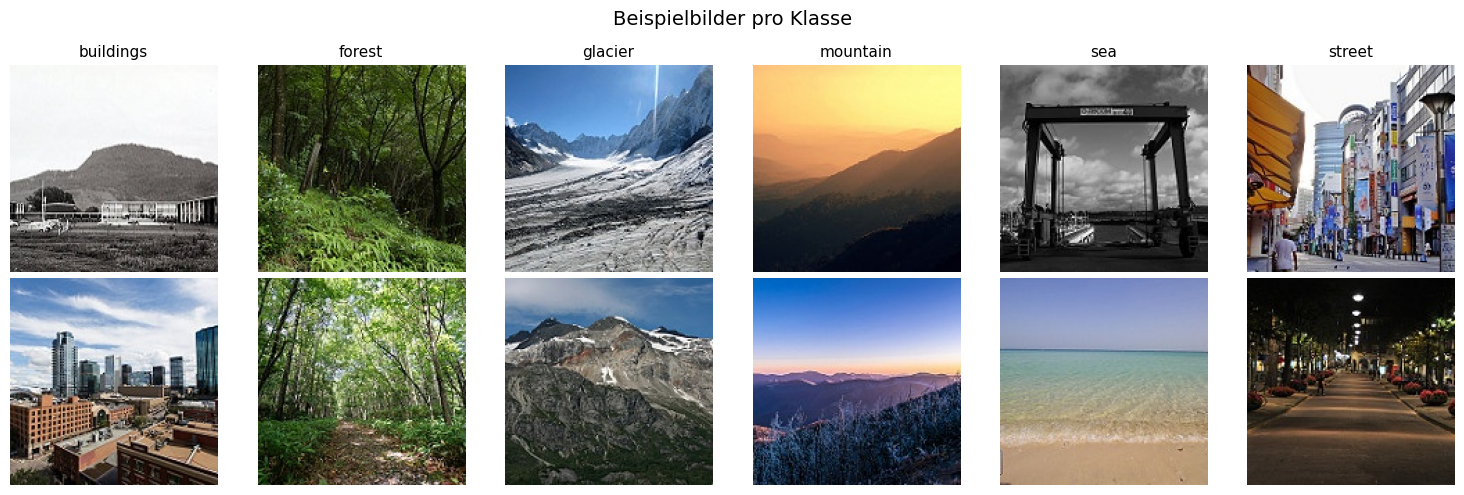

In [4]:
# Beispielbilder pro Klasse anzeigen
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle("Beispielbilder pro Klasse", fontsize=14)

for class_idx, class_name in enumerate(label_names):
    class_samples = dataset["train"].filter(lambda x: x["label"] == class_idx)
    for row in range(2):
        ax = axes[row, class_idx]
        ax.imshow(class_samples[row]["image"])
        ax.axis("off")
        if row == 0:
            ax.set_title(class_name, fontsize=11)

plt.tight_layout()
plt.show()

### Fazit Beispielbilder pro Klasse

Meine vorhersage für die Modelle ist: 
- Die Klasse `forest` wird wahrscheinlich am einfachstenzu unterscheiden sein. 
- Die Klassen `buildings` und `street` könnten Problematisch zu unterscheiden sein. Bei dem ersten Beispielbild von `street` sieht man auch Gebäude was schwer zu unterscheiden sein kann für das Modell.
- Auch die Klassen `glacier` und `mountain` können schwer vorhersagbar sein für das Modell, da bei den `glacier` Beispielbildern auch Berge zu sehen sind. 
- Bei dem ersten Beispielbild von `sea` ist zu erkennen, dass der Datensatz auch Schwarz-Weiss Bilder enthält. Das Modell kann sich somit nicht lediglich auf die Farbkanäle verlassen. 

### Bildgrössen und Pixelwerte

Prüfen, ob alle Bilder die gleiche Grösse haben und wie der Wertebereich aussieht.

In [5]:
# Bildgrössen in allen Splits prüfen
train_sizes = [dataset["train"][i]["image"].size for i in range(len(dataset["train"]))]
test_sizes = [dataset["test"][i]["image"].size for i in range(len(dataset["test"]))]

unique_train_sizes = set(train_sizes)
unique_test_sizes = set(test_sizes)

print(f"Einzigartige Bildgrössen im Train-Split: {unique_train_sizes}")
print(f"Einzigartige Bildgrössen im Test-Split:  {unique_test_sizes}")

sample_img = dataset["train"][0]["image"]
img_array = np.array(sample_img)
print(f"\nShape eines Beispielbildes: {img_array.shape}")
print(f"Wertebereich: [{img_array.min()}, {img_array.max()}]")
print(f"Dtype: {img_array.dtype}")

Einzigartige Bildgrössen im Train-Split: {(150, 136), (150, 81), (150, 145), (150, 142), (150, 105), (150, 102), (150, 108), (150, 111), (150, 120), (150, 123), (150, 135), (150, 141), (150, 144), (150, 150), (150, 147), (150, 110), (150, 113), (150, 119), (150, 131), (150, 76), (150, 134), (150, 140), (150, 143), (150, 146), (150, 149), (150, 100), (150, 97), (150, 103), (150, 115), (150, 124), (150, 133)}
Einzigartige Bildgrössen im Test-Split:  {(150, 149), (150, 110), (150, 81), (150, 141), (150, 131), (150, 76), (150, 150), (150, 72)}

Shape eines Beispielbildes: (150, 150, 3)
Wertebereich: [0, 255]
Dtype: uint8


### Fazit Bildgrössen

Die Bilddimensionen sind in der Höhe immer 150 pixel. In der Breite variieren die Bilder jedoch. Im Trainings Datensatz ist die Bildbreite zwischen 81 pixel und 150 pixel. Im Test Datensatz sind die Bildbreiten zwischen 72 pixel und 150 pixeln. 

Dies muss bei dem Preprocessing Berücksichtigt werden. 

### Pixelwert-Verteilung pro Kanal pro Klasse

Boxplot der mittleren Pixelwerte pro RGB-Kanal, aufgeschlüsselt nach Klasse (je 200 Bilder pro Klasse). So lässt sich erkennen, ob bestimmte Klassen systematisch andere Farbverteilungen aufweisen.

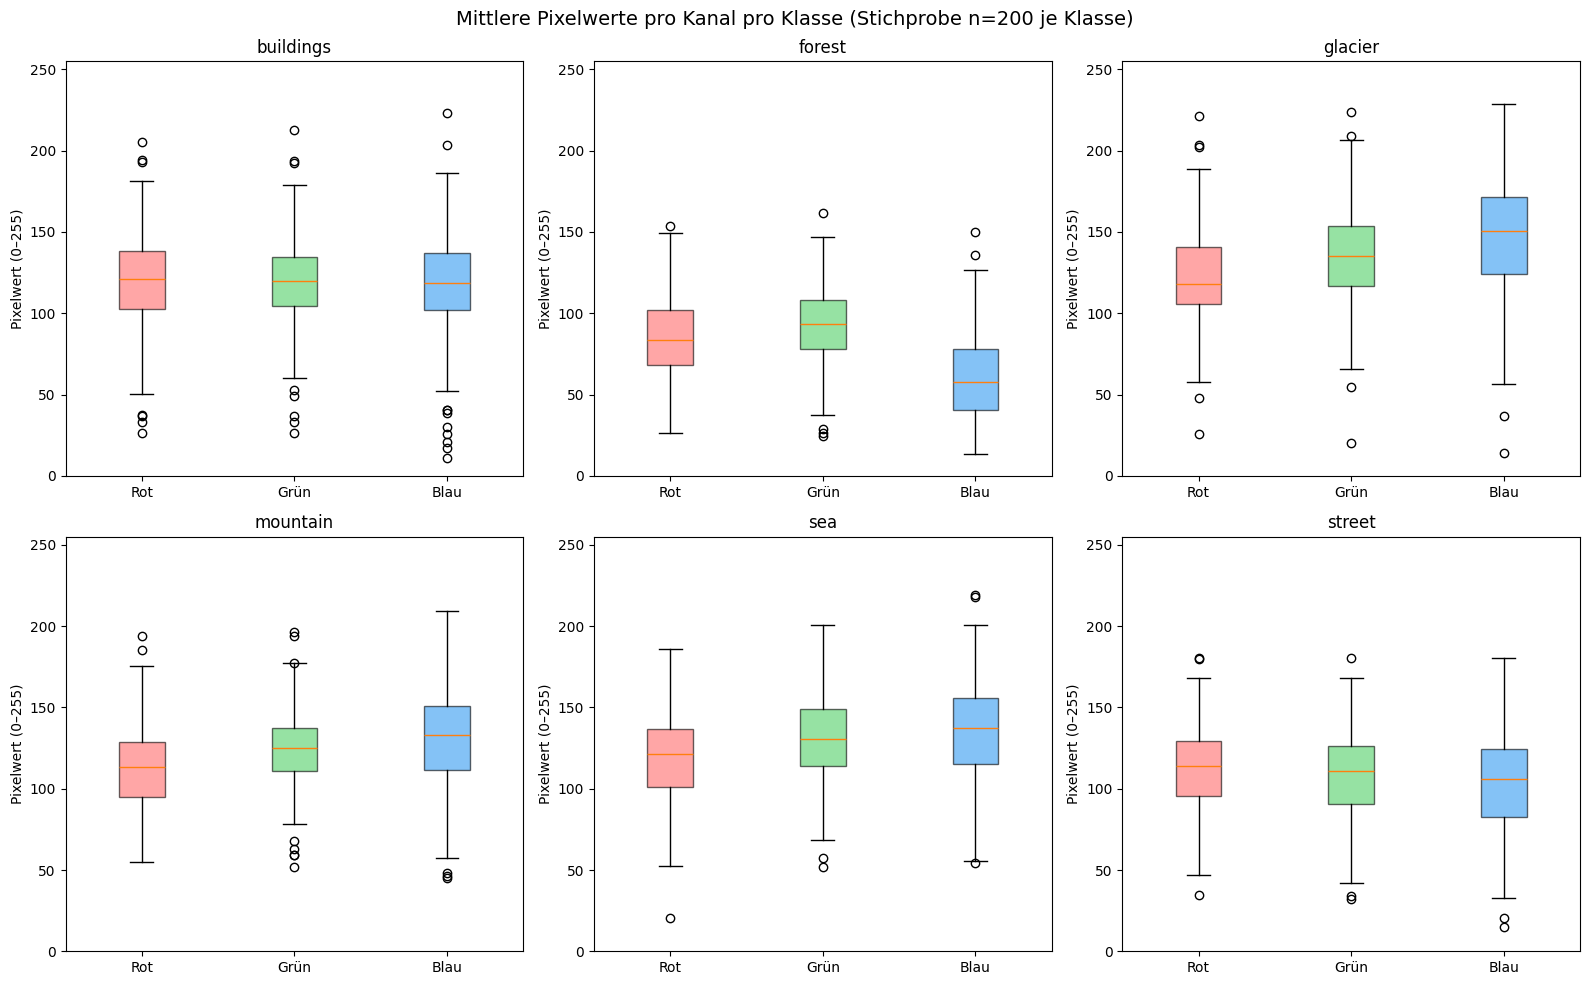


Klasse              R        G        B
--------------------------------------
buildings       118.8    119.4    118.1
forest           84.9     92.3     60.7
glacier         120.4    134.2    146.1
mountain        113.4    124.6    131.2
sea             119.0    129.4    136.8
street          111.5    107.5    103.6


In [6]:
# Pixelwert-Verteilung pro Kanal pro Klasse
rng = np.random.default_rng(RANDOM_SEED)
n_samples_per_class = 200
all_labels = dataset["train"]["label"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Mittlere Pixelwerte pro Kanal pro Klasse (Stichprobe n=200 je Klasse)", fontsize=14
)

summary = {}

for class_idx, class_name in enumerate(label_names):
    ax = axes[class_idx // 3, class_idx % 3]

    class_indices = [i for i, lbl in enumerate(all_labels) if lbl == class_idx]
    sample_indices = rng.choice(
        class_indices, size=min(n_samples_per_class, len(class_indices)), replace=False
    )

    pixel_data = {"R": [], "G": [], "B": []}
    for idx in sample_indices:
        img = np.array(dataset["train"][int(idx)]["image"])
        for c, name in enumerate(["R", "G", "B"]):
            pixel_data[name].append(img[:, :, c].mean())

    summary[class_name] = pixel_data

    bp = ax.boxplot(
        [pixel_data["R"], pixel_data["G"], pixel_data["B"]],
        tick_labels=["Rot", "Grün", "Blau"],
        patch_artist=True,
    )
    colors = ["#FF6B6B", "#51CF66", "#339AF0"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(class_name, fontsize=12)
    ax.set_ylabel("Pixelwert (0–255)")
    ax.set_ylim(0, 255)

plt.tight_layout()
plt.show()

# Zusammenfassung: Mittelwerte pro Klasse und Kanal
print(f"\n{'Klasse':<12} {'R':>8} {'G':>8} {'B':>8}")
print("-" * 38)
for class_name, data in summary.items():
    print(
        f"{class_name:<12} {np.mean(data['R']):>8.1f} {np.mean(data['G']):>8.1f} {np.mean(data['B']):>8.1f}"
    )

### Fazit der mittleren Farbkanalwerte pro Klasse
**Beobachtungen:**

- `forest` ist die am einfachsten unterscheidbare Klasse: Sie hat die niedrigste Gesamthelligkeit und eine Grün Dominanz. Der blaue Kanal ist mit 60.7 der niedrigste Wert im gesamten Datensatz.
- `glacier`, `mountain` und `sea` bilden ein problematisches Cluster. Alle drei Klassen sind blau dominant und liegen in der Gesamthelligkeit nahe beieinander. Die Farbinformation allein reicht hier nicht aus, um zuverlässig zwischen diesen Klassen zu unterscheiden.
- `buildings` zeigt ein nahezu perfekt neutrales Farbprofil. Rot, Grün und Blau sind sehr ausgeglichen. 
- `street` ist ebenfalls relativ ausgeglichen, wobei rot am dominantesten ist. Die `street` Pixelverteilung ist dazu noch leicht tiefer (dünkler) als die `buildings` Pixelwerte

**Implikationen für das Modell:**

1. **Farbinformation ist notwendig, aber nicht hinreichend.** Während Forest anhand der Farbverteilung gut trennbar ist, muss das CNN für die Unterscheidung von Glacier/Mountain/Sea auf **Textur- und Strukturmerkmale** (Kanten, Muster, räumliche Frequenzen) zurückgreifen. Das zeigt, wie wichtig die Convolutional Layers sind.
2. **Normalisierung ist wichtig.** Die Mittelwerte weichen deutlich von 128 (Mitte des [0, 255]-Bereichs) ab und unterscheiden sich zwischen den Kanälen. Eine kanalweise Normalisierung (z.B. mit den berechneten Mittelwerten und Standardabweichungen) hilft dem Modell, schneller zu konvergieren, da die Eingabedaten zentriert und skaliert werden.
3. **Verwechslungsrisiken** sind vorhersehbar: Die Confusion Matrix wird vermutlich erhöhte Verwechslungsraten zwischen Glacier ↔ Mountain ↔ Sea sowie zwischen Buildings ↔ Street zeigen. Dies haben ich bereits in den Beispielbildern zum Teil vorhergesagt. 

## Preprocessing

### Train/Validation-Split und Kanal-Statistiken berechnen

Zuerst wird der Train/Validation-Split (80/20, stratifiziert) durchgeführt. Danach werden Mittelwerte und Standardabweichungen pro RGB-Kanal **ausschliesslich über den Trainings-Split** berechnet, nicht über den gesamten Datensatz, um Data Leakage zu vermeiden.

Der Validation Split entsteht aus 20% von den vorgegebenen trainings Datensatz. 
- `train`:        80% von dem **Train** Datensatz
- `validation`:   20% von dem **Train** Datensatz
- `test`:         100% von dem **Test** Datensatz

In [7]:
# Train/Validation-Split zuerst, damit Kanal-Statistiken nur auf Trainingsdaten berechnet werden
train_indices, val_indices = train_test_split(
    range(len(dataset["train"])),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=dataset["train"]["label"],
)

# Kanal-Mittelwerte und Standardabweichungen NUR über den Train-Split berechnen
# Validation- und Test-Daten dürfen nicht einfliessen (Data Leakage)
channel_sum = np.zeros(3)
channel_sq_sum = np.zeros(3)
n_pixels = 0

for i in train_indices:
    img = np.array(dataset["train"][i]["image"], dtype=np.float32) / 255.0
    channel_sum += img.sum(axis=(0, 1))
    channel_sq_sum += (img**2).sum(axis=(0, 1))
    n_pixels += img.shape[0] * img.shape[1]

channel_mean = channel_sum / n_pixels
channel_std = np.sqrt(channel_sq_sum / n_pixels - channel_mean**2)

print(f"Train-Split: {len(train_indices)} Bilder, Val-Split: {len(val_indices)} Bilder")
print(f"Channel means (nur Train-Split): {channel_mean}")
print(f"Channel stds  (nur Train-Split): {channel_std}")

Train-Split: 11227 Bilder, Val-Split: 2807 Bilder
Channel means (nur Train-Split): [0.43018795 0.45737195 0.45355669]
Channel stds  (nur Train-Split): [0.26945614 0.26800597 0.29854997]


### Transform-Pipeline

**Train Pipeline**
- `RandomResizedCrop` (64x64) für Training: Aus den ~150x150 Bildern wird pro Aufruf ein zufälliger 64x64-Ausschnitt genommen. Der Ausschnitt darf zwischen 40% und 100% gross sein. Das wirkt als Data Augmentation.
- `RandomHorizontalFlip` Die Bilder werden mit einer Wahrscheinlichkeit von 50% Horizontal geflipped. Das macht das Modell robuster. 
- `ToTensor` wandelt die Bilder von einem PIL-Bild zu einem PyTorch-Tensor um. Dabei wird:
  - Wertebereich von 0–255 auf 0–1 skaliert
  - Format wird von HWC (64, 64, 3) zu CHW (3, 64, 64) geändert
- `Normalize` Hier werden die Pixelwerte pro Farbkanal normalisiert.
  - $x_{neu} = \frac{x - \text{mean}}{\text{std}}$

**Validation und Test Pipeline**
- `Resize` (64x64): Das gesamte Bild wird auf 64x64 herunter skaliert, damit keine Bildinformation durch Cropping verloren geht und die Evaluation auf dem vollständigen Bildinhalt basiert.

In [8]:
# Train: RandomResizedCrop + HorizontalFlip als Data Augmentation
transform_train = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            64, scale=(0.4, 1.0)
        ),  # TODO Fragen ob bei Etappe bereits erlaubt ist.
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),  # PIL -> Tensor [0,1], HWC -> CHW
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)


# Validation/Test: CenterCrop für deterministische Evaluation
transform_eval = transforms.Compose(
    [
        transforms.Resize((64, 64)),  # Beide Dimensionen auf 64x64 erzwingen
        transforms.ToTensor(),
        transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist()),
    ]
)

### PyTorch Dataset-Wrapper

Wrapper-Klasse, die das HuggingFace Dataset in ein PyTorch Dataset konvertiert und den Transform anwendet.

In [9]:
# PyTorch Dataset-Wrapper für HuggingFace Dataset
class IntelImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

### Train/Validation/Test-Split

train_indices und val_indices wurden bereits oben erstellt (80/20, stratifiziert). Hier werden die HuggingFace-Subsets und PyTorch Datasets daraus erzeugt. Das Testset bleibt unverändert.

In [10]:
# train_indices und val_indices wurden oben bei der Kanal-Statistik-Berechnung erstellt
hf_train = dataset["train"].select(train_indices)
hf_val = dataset["train"].select(val_indices)

train_dataset = IntelImageDataset(hf_train, transform=transform_train)
val_dataset = IntelImageDataset(hf_val, transform=transform_eval)
test_dataset = IntelImageDataset(dataset["test"], transform=transform_eval)

print(f"Train:      {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test:       {len(test_dataset)} Bilder")

Train:      11227 Bilder
Validation: 2807 Bilder
Test:       3000 Bilder


### DataLoaders erstellen

DataLoader für Train, Validation und Test mit initialer Batch-Size von 64. Sanity Check der Batch-Dimensionen und Pixelwerte.

In [11]:
# DataLoaders erstellen
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sanity Check: ein Batch laden
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # [64, 3, 150, 150]
print(f"Labels shape: {labels.shape}")  # [64]
print(f"Pixel range:  [{images.min():.2f}, {images.max():.2f}]")

Batch shape: torch.Size([64, 3, 64, 64])
Labels shape: torch.Size([64])
Pixel range:  [-1.71, 2.11]


## Schritt 1: Setup (Device, Metriken, W&B)

Als Kostenfunktion (Loss-Funktion) wird `CrossEntropyLoss` verwendet. `CrossEntropyLoss` wird verwendet, weil das Modell Bilder mehreren möglichen Klassen zuordnen soll, wobei jedes Bild genau eine richtige Klasse besitzt. Die Funktion misst, wie gut die Vorhersage des Modells mit dem tatsächlichen Klassenlabel übereinstimmt, und eignet sich deshalb gut für Multiclass-Classification.

In [12]:
# Device Setup (Apple Silicon MPS / CUDA / CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Device: {device}")

# Kostenfunktion
criterion = nn.CrossEntropyLoss()

# Klassennamen
NUM_CLASSES = 6
CLASS_NAMES = dataset["train"].features["label"].names
print(f"Klassen ({NUM_CLASSES}): {CLASS_NAMES}")

Device: mps
Klassen (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### W&B Login

Authentifizierung bei Weights & Biases für Experiment-Tracking.

In [13]:
# W&B Login
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/lucamanna/.netrc.
wandb: Currently logged in as: mannaluca02 (mannaluca02-fachhochschule-nordwestschweiz-fhnw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Schritt 2: Training- und Evaluierungsfunktionen

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Trainiert eine Epoche. Gibt (loss, accuracy) zurück."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = criterion(pred, Y)

        optimizer.zero_grad()  # entfernt alte Gradienten
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (pred.argmax(dim=1) == Y).sum().item()
        total += Y.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Evaluiert das Modell. Gibt (loss, accuracy) zurück."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Keine Gradientenberechnung für Evaluation
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            total_loss += criterion(pred, Y).item()
            correct += (pred.argmax(dim=1) == Y).sum().item()
            total += Y.size(0)

    return total_loss / len(loader), correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    log_wandb=True,
):
    """Kompletter Trainingsloop mit optionalem W&B-Logging. Gibt History-Dict zurück."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if log_wandb:
            wandb.log(
                {
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                }
            )

        print(
            f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
        )

    elapsed = time.time() - start_time
    minutes, seconds = divmod(elapsed, 60)
    print(
        f"\nTraining abgeschlossen in {int(minutes)}m {seconds:.1f}s ({epochs} Epochen, {elapsed/epochs:.2f}s/Epoche)"
    )

    return history


def plot_training(history, title="Lernkurven"):
    """Plottet Loss und Accuracy (Train vs Val). Gibt die Figure zurück."""
    epochs = range(len(history["train_loss"]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], "b-", label="Train")
    ax1.plot(epochs, history["val_loss"], "r-", label="Validation")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], "b-", label="Train")
    ax2.plot(epochs, history["val_acc"], "r-", label="Validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

### Evaluierungs- und Visualisierungsfunktionen

- **Lernkurven** (Train Loss / Val Loss / Train Accuracy / Val Accuracy): wie sich das Modell über die Epochen entwickelt.
- **Generalization Gap**: zeigt direkt den Unterschied zwischen Trainings- und Validierungsleistung.
- **Confusion Matrix**: Sie zeigt für jede Klasse:
  - wie oft sie korrekt erkannt wurde
  - mit welchen anderen Klassen sie verwechselt wurde
- **Per-Class Metrics**: Balkendiagramm pro Klasse mit folgenden Werten:
  - Precision
  - Recall
  - F1-Score
- **Top-Loss Samples**: Zeigt die Beispiele bei denen das Modell die grössten Schwierigkeiten hatte.
- **Cross-Validation Boxplot**: wie stabil das Modell über verschiedene Folds hinweg performt.


In [15]:
def denormalize(tensor, mean, std):
    """Denormalisiert einen Bild-Tensor für die Anzeige."""
    mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
    std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


def collect_predictions(model, loader, device):
    """Sammelt Bilder, Predictions, Labels und Per-Sample-Losses vom gesamten Loader."""
    model.eval()
    all_images, all_labels, all_preds, all_probs, all_losses = [], [], [], [], []
    with torch.no_grad():
        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            logits = model(X)
            probs = torch.softmax(logits, dim=1)
            losses = F.cross_entropy(logits, Y, reduction="none")
            all_images.append(X.cpu())
            all_labels.append(Y.cpu())
            all_preds.append(logits.argmax(dim=1).cpu())
            all_probs.append(probs.cpu())
            all_losses.append(losses.cpu())
    return {
        "images": torch.cat(all_images),
        "y_true": torch.cat(all_labels).numpy(),
        "y_pred": torch.cat(all_preds).numpy(),
        "y_probs": torch.cat(all_probs).numpy(),
        "losses": torch.cat(all_losses).numpy(),
    }


def plot_cv_boxplot(fold_results, title="Cross-Validation Accuracy"):
    """Box-Plot und Einzelwerte der Cross-Validation Ergebnisse."""
    best_accs = [r["best_val_acc"] for r in fold_results]
    final_accs = [r["final_val_acc"] for r in fold_results]

    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(
        [best_accs, final_accs],
        tick_labels=["Best Val Acc", "Final Val Acc"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#2196F3")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("#FF9800")
    bp["boxes"][1].set_alpha(0.6)

    for i, data in enumerate([best_accs, final_accs], 1):
        ax.scatter([i] * len(data), data, color="black", zorder=5, s=50)
        for j, val in enumerate(data):
            ax.annotate(f"  Fold {j + 1}", (i, val), fontsize=8, va="center")

    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
    return fig


def evaluate_model(
    model,
    loader,
    class_names,
    device,
    mean,
    std,
    top_n_loss=16,
    log_wandb=True,
):
    """Sammelt Predictions und loggt alle Rohdaten zu W&B, damit Confusion Matrix,
    Per-Class Metrics und Top-Loss Samples im W&B-Report interaktiv dargestellt werden.
    Erzeugt keine Plots im Notebook."""
    results = collect_predictions(model, loader, device)
    y_true = results["y_true"]
    y_pred = results["y_pred"]

    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )
    acc = float(np.mean(y_true == y_pred))

    if log_wandb and wandb.run is not None:
        # Confusion Matrix — native interaktiv via wandb.plot.confusion_matrix
        wandb.log(
            {
                "eval/confusion_matrix": wandb.plot.confusion_matrix(
                    y_true=y_true, preds=y_pred, class_names=class_names
                )
            }
        )

        # Drei separate native Bar-Charts via wandb.plot.bar.
        # Enthalten alle Klassen + macro/weighted avg als Summary-Rows.
        groups = list(class_names) + ["macro avg", "weighted avg"]
        bar_panels = {}
        for metric, panel_key, title in [
            ("precision", "eval/per_class_precision", "Per-Class Precision"),
            ("recall", "eval/per_class_recall", "Per-Class Recall"),
            ("f1-score", "eval/per_class_f1", "Per-Class F1-Score"),
        ]:
            tbl = wandb.Table(
                columns=["class", metric],
                data=[[g, float(report[g][metric])] for g in groups],
            )
            bar_panels[panel_key] = wandb.plot.bar(tbl, "class", metric, title=title)
        wandb.log(bar_panels)

        # Classification Report als flache Tabelle (für Detail-Ansicht im Report)
        wandb.log(
            {
                "eval/classification_report": wandb.Table(
                    columns=["class", "precision", "recall", "f1-score", "support"],
                    data=[
                        [
                            name,
                            report[name]["precision"],
                            report[name]["recall"],
                            report[name]["f1-score"],
                            int(report[name]["support"]),
                        ]
                        for name in class_names
                    ],
                ),
                "eval/accuracy": acc,
            }
        )

        # Top-Loss Samples als Table mit Bildern → sortierbares Panel im Report
        # Zusaetzliche Spalte "run" erleichtert Zuordnung beim Vergleich mehrerer Modelle.
        run_name = wandb.run.name if wandb.run is not None else "unknown"
        top_idx = np.argsort(results["losses"])[-top_n_loss:][::-1]
        top_loss_table = wandb.Table(
            columns=["run", "image", "true", "pred", "confidence", "loss"]
        )
        for idx in top_idx:
            img = (
                denormalize(results["images"][idx], mean, std).permute(1, 2, 0).numpy()
            )
            top_loss_table.add_data(
                run_name,
                wandb.Image(img),
                class_names[int(y_true[idx])],
                class_names[int(y_pred[idx])],
                float(results["y_probs"][idx][int(y_pred[idx])]),
                float(results["losses"][idx]),
            )
        wandb.log({"eval/top_loss_samples": top_loss_table})

    print(f"\nGesamtgenauigkeit: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return results

### Hyperparameter-Vergleichs-Visualisierungen

- **Vergleichsplot für Loss und Accuracy**: zeigt, wie sich verschiedene Hyperparameterwerte über die Epochen hinweg auf Trainings- und Validierungsleistung auswirken.
- **Beste Validation Accuracy pro Hyperparameterwert**: Balkendiagramm, das den besten erreichten Validierungswert pro getesteter Konfiguration darstellt.
- **Generalization Gap im Hyperparametervergleich**: zeigt für verschiedene Hyperparameterwerte den Unterschied zwischen Validierungs- und Trainings-Loss und hilft, Overfitting zu erkennen.

In [16]:
def plot_hp_comparison(histories, hp_name="hp", hp_label="Hyperparameter"):
    """Vergleichsplot: Train (solid) + Val (gestrichelt) fuer Loss und Accuracy."""
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(histories)))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for (hp_val, hist), color in zip(histories.items(), colors):
        epochs = range(len(hist["train_loss"]))
        ax1.plot(
            epochs,
            hist["train_loss"],
            "-",
            color=color,
            alpha=0.7,
            label=f"{hp_name}={hp_val}",
        )
        ax1.plot(epochs, hist["val_loss"], "--", color=color, alpha=0.7)
        ax2.plot(
            epochs,
            hist["train_acc"],
            "-",
            color=color,
            alpha=0.7,
            label=f"{hp_name}={hp_val}",
        )
        ax2.plot(epochs, hist["val_acc"], "--", color=color, alpha=0.7)

    # Linestyle-Legende: solid=Train, dashed=Validation
    style_handles = [
        Line2D([0], [0], color="gray", linestyle="-", label="Train"),
        Line2D([0], [0], color="gray", linestyle="--", label="Validation"),
    ]

    for ax, ylabel, title_suffix in [
        (ax1, "Loss", "Loss"),
        (ax2, "Accuracy", "Accuracy"),
    ]:
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{hp_label}-Tuning — {title_suffix}")
        handles, _ = ax.get_legend_handles_labels()
        ax.legend(handles=handles + style_handles, fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_hp_best_accuracy(histories, hp_name="hp", hp_label="Hyperparameter"):
    """Balkendiagramm: Beste Validation Accuracy pro HP-Wert mit Epoche."""
    hp_vals = list(histories.keys())
    best_accs = [max(h["val_acc"]) for h in histories.values()]
    best_epochs = [int(np.argmax(h["val_acc"])) for h in histories.values()]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(range(len(hp_vals)), best_accs, color="#2196F3", alpha=0.8)
    ax.set_xticks(range(len(hp_vals)))
    ax.set_xticklabels([f"{hp_name}={v}" for v in hp_vals], rotation=45, ha="right")
    ax.set_ylabel("Best Validation Accuracy")
    ax.set_title(f"{hp_label}-Tuning — Beste Validation Accuracy")
    ax.set_ylim(min(best_accs) - 0.05, max(best_accs) + 0.03)
    ax.grid(True, alpha=0.3, axis="y")

    for bar, acc, epoch in zip(bars, best_accs, best_epochs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{acc:.3f}\n(Ep. {epoch})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # Besten Balken hervorheben
    best_idx = int(np.argmax(best_accs))
    bars[best_idx].set_color("#4CAF50")

    plt.tight_layout()
    plt.show()
    return fig


def plot_hp_gap_comparison(histories, hp_name="hp", hp_label="Hyperparameter"):
    """Generalization Gap (Val Loss - Train Loss) im Vergleich ueber mehrere HP-Werte."""
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(histories)))
    fig, ax = plt.subplots(figsize=(10, 5))

    for (hp_val, hist), color in zip(histories.items(), colors):
        epochs = range(len(hist["train_loss"]))
        gap = [v - t for t, v in zip(hist["train_loss"], hist["val_loss"])]
        ax.plot(epochs, gap, color=color, linewidth=1.5, label=f"{hp_name}={hp_val}")

    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss - Train Loss")
    ax.set_title(f"{hp_label}-Tuning — Generalization Gap")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

### Cross-Validation-Visualisierungen

- **Mean ± Std Band für Loss und Accuracy**: zeigt den durchschnittlichen Trainings- und Validierungsverlauf über alle Folds hinweg sowie die Streuung der Ergebnisse.
- **Per-Class Accuracy pro Fold**: gruppiertes Balkendiagramm, das die Accuracy jeder Klasse für jeden einzelnen Fold darstellt.
- **Mean ± Std der Per-Class Accuracy**: ergänzt die klassenweisen Fold-Ergebnisse durch den Mittelwert und die Standardabweichung, um die Stabilität der Klassenleistung über alle Folds hinweg sichtbar zu machen.

In [17]:
def plot_cv_mean_std_band(fold_results, title_prefix="Cross-Validation"):
    """Mean +/- Std Band ueber alle Folds fuer Loss und Accuracy."""
    n_epochs = min(len(r["history"]["val_loss"]) for r in fold_results)

    # Sammle Metriken pro Epoche
    val_losses = np.array([r["history"]["val_loss"][:n_epochs] for r in fold_results])
    val_accs = np.array([r["history"]["val_acc"][:n_epochs] for r in fold_results])
    train_losses = np.array(
        [r["history"]["train_loss"][:n_epochs] for r in fold_results]
    )
    train_accs = np.array([r["history"]["train_acc"][:n_epochs] for r in fold_results])
    epochs = np.arange(n_epochs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    for data, color, label in [
        (train_losses, "#2196F3", "Train"),
        (val_losses, "#E53935", "Validation"),
    ]:
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        ax1.plot(epochs, mean, color=color, linewidth=2, label=f"{label} (Mean)")
        ax1.fill_between(
            epochs,
            mean - std,
            mean + std,
            color=color,
            alpha=0.15,
            label=f"{label} (±1 Std)",
        )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title_prefix} — Loss (Mean ± Std)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Accuracy
    for data, color, label in [
        (train_accs, "#2196F3", "Train"),
        (val_accs, "#E53935", "Validation"),
    ]:
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        ax2.plot(epochs, mean, color=color, linewidth=2, label=f"{label} (Mean)")
        ax2.fill_between(
            epochs,
            mean - std,
            mean + std,
            color=color,
            alpha=0.15,
            label=f"{label} (±1 Std)",
        )

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title_prefix} — Accuracy (Mean ± Std)")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_cv_per_class_accuracy(
    fold_predictions,
    class_names,
    title="Cross-Validation — Per-Class Accuracy pro Fold",
):
    """Gruppiertes Balkendiagramm: Accuracy pro Klasse, aufgeschluesselt nach Fold."""
    n_folds = len(fold_predictions)
    n_classes = len(class_names)

    # Per-Class Accuracy pro Fold berechnen
    per_class_accs = np.zeros((n_folds, n_classes))
    for f_idx, pred in enumerate(fold_predictions):
        for c_idx in range(n_classes):
            mask = pred["y_true"] == c_idx
            if mask.sum() > 0:
                per_class_accs[f_idx, c_idx] = (pred["y_pred"][mask] == c_idx).mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(n_classes)
    width = 0.8 / n_folds

    for f_idx in range(n_folds):
        offset = (f_idx - n_folds / 2 + 0.5) * width
        ax.bar(
            x + offset,
            per_class_accs[f_idx],
            width,
            label=f"Fold {f_idx + 1}",
            alpha=0.8,
        )

    # Mean + Std als Fehlerbalken
    mean_accs = per_class_accs.mean(axis=0)
    std_accs = per_class_accs.std(axis=0)
    ax.errorbar(
        x,
        mean_accs,
        yerr=std_accs,
        fmt="ko",
        capsize=5,
        capthick=2,
        linewidth=0,
        elinewidth=2,
        label="Mean ± Std",
        zorder=5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()
    return fig

## Schritt 3: CNN-Basismodell

Architektur für 64x64x3 Bilder (Resize zur Verkürzung der Trainingszeit):
- 3 Conv-Blöcke (Conv2d + ReLU + MaxPool2d) für Feature-Extraktion
- 2 Fully Connected Layers für Klassifikation
- Kein Dropout, kein BatchNorm (Vorgabe Stage 1)
- Output: raw logits (CrossEntropyLoss enthält Softmax)
- Die Linear-Layer-Grösse wird automatisch aus der Bildgrösse berechnet

In [18]:
IMG_SIZE = 64  # Muss mit transforms.Resize übereinstimmen


class BaseCNN(nn.Module):
    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Feature-Map-Grösse nach 3x MaxPool2d(2)
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Modell instanzieren und Architektur prüfen
model = BaseCNN(NUM_CLASSES).to(device)
print(model)
print(f"\nParameter: {sum(p.numel() for p in model.parameters()):,}")

# Forward-Pass Test mit aktueller Bildgrösse
with torch.no_grad():
    test_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
    test_output = model(test_input)
    print(f"\nInput:  {test_input.shape}")
    print(f"Output: {test_output.shape}")  # Erwartet: [2, 6]

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

Parameter: 548,774

Input:  torch.Size([2, 3, 64, 64])
Output: torch.Size([2, 6])


## Schritt 4: Overfitting-Test

Laut Aufgabenstellung (Punkt 3d): Trainiere auf einem einzelnen Batch. Der Loss muss gegen 0 gehen. Das bestätigt, dass Modell und Training-Loop korrekt funktionieren.

Epoch   0 | Train Loss: 1.7883  Acc: 0.1406 | Val Loss: 1.7796  Acc: 0.3438
Epoch   1 | Train Loss: 1.7796  Acc: 0.3438 | Val Loss: 1.7721  Acc: 0.3281
Epoch   2 | Train Loss: 1.7721  Acc: 0.3281 | Val Loss: 1.7650  Acc: 0.3594
Epoch   3 | Train Loss: 1.7650  Acc: 0.3594 | Val Loss: 1.7577  Acc: 0.3281
Epoch   4 | Train Loss: 1.7577  Acc: 0.3281 | Val Loss: 1.7502  Acc: 0.3438
Epoch   5 | Train Loss: 1.7502  Acc: 0.3438 | Val Loss: 1.7417  Acc: 0.3594
Epoch   6 | Train Loss: 1.7417  Acc: 0.3594 | Val Loss: 1.7321  Acc: 0.3438
Epoch   7 | Train Loss: 1.7321  Acc: 0.3438 | Val Loss: 1.7211  Acc: 0.3438
Epoch   8 | Train Loss: 1.7211  Acc: 0.3438 | Val Loss: 1.7087  Acc: 0.3438
Epoch   9 | Train Loss: 1.7087  Acc: 0.3438 | Val Loss: 1.6947  Acc: 0.3438
Epoch  10 | Train Loss: 1.6947  Acc: 0.3438 | Val Loss: 1.6792  Acc: 0.3438
Epoch  11 | Train Loss: 1.6792  Acc: 0.3438 | Val Loss: 1.6617  Acc: 0.3438
Epoch  12 | Train Loss: 1.6617  Acc: 0.3438 | Val Loss: 1.6424  Acc: 0.3438
Epoch  13 | 

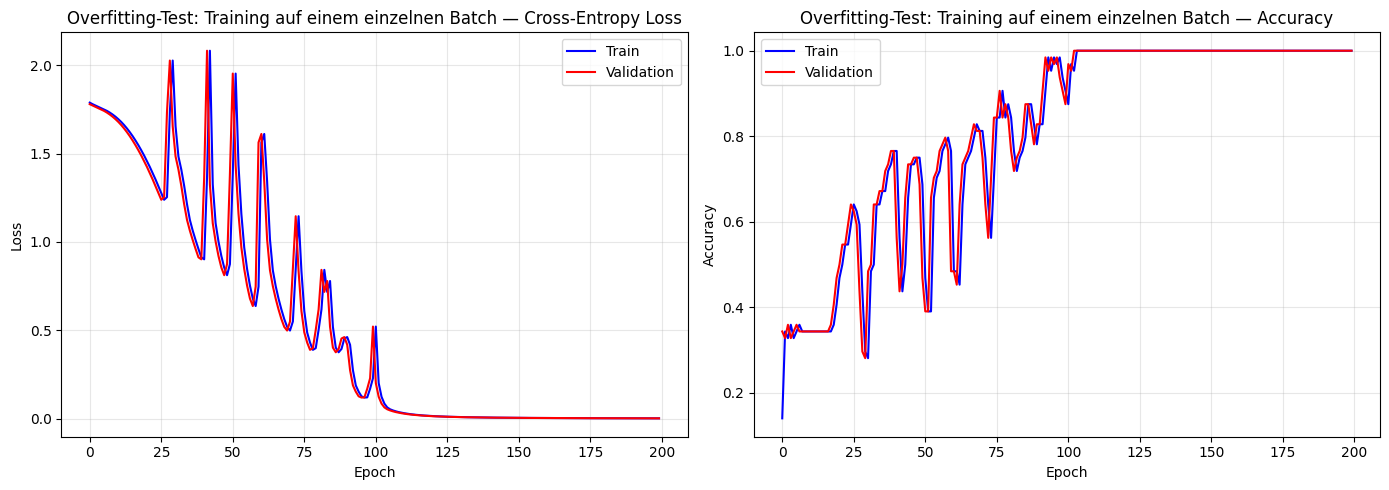


Final Loss: 0.001984 | Final Acc: 1.0000
BESTANDEN — Modell kann einen Batch overfitten. Training-Loop funktioniert korrekt.


In [19]:
# Overfitting-Test: ein einzelner Batch, 200 Iterationen mit höherer LR
# Verwendet train_model() und evaluate(), um gleichzeitig den Training-Loop zu validieren.

overfit_model = BaseCNN(NUM_CLASSES).to(device)
overfit_optimizer = optim.SGD(overfit_model.parameters(), lr=0.05)

# Einen Batch extrahieren und als DataLoader wrappen
single_batch_X, single_batch_Y = next(iter(train_loader))
single_batch_dataset = TensorDataset(single_batch_X, single_batch_Y)
single_batch_loader = DataLoader(single_batch_dataset, batch_size=len(single_batch_X))

# 200 Epochs = 200 Iterationen (Loader enthält nur 1 Batch)
history_overfit = train_model(
    overfit_model,
    single_batch_loader,
    single_batch_loader,  # Val = gleicher Batch (Overfitting-Test)
    criterion,
    overfit_optimizer,
    device,
    epochs=200,
    log_wandb=False,
)

plot_training(
    history_overfit, title="Overfitting-Test: Training auf einem einzelnen Batch"
)

final_loss = history_overfit["train_loss"][-1]
final_acc = history_overfit["train_acc"][-1]
print(f"\nFinal Loss: {final_loss:.6f} | Final Acc: {final_acc:.4f}")
if final_loss < 0.01 and final_acc > 0.99:
    print(
        "BESTANDEN — Modell kann einen Batch overfitten. Training-Loop funktioniert korrekt."
    )
else:
    print("NICHT BESTANDEN — Loss konvergiert nicht gegen 0.")

### Beobachtungen Overfitting-Test

**Train vs. Validation identisch:** Da beide Kurven auf exakt denselben Daten operieren (gleicher DataLoader für Train und Validation), liegen sie nahezu perfekt übereinander. Der minimale Unterschied entsteht dadurch, dass `train_epoch()` im `model.train()`-Modus läuft und die Metriken **während** des Gradientenupdates berechnet (der Loss am Anfang des Batches, bevor die Gewichte aktualisiert werden), während `evaluate()` im `model.eval()`-Modus die Metriken **nach** dem Update berechnet. Daher ist die rote Validation-Kurve immer minimal besser als die blaue Train-Kurve.


**Spikes im Verlauf:** Die Spikes entstehen durch die Kombination aus hoher Lernrate (0.05) und SGD ohne Momentum auf nur einem einzigen Batch. Bei einem einzelnen Batch von 64 Bildern ist die Loss-Landschaft nicht glatt, sondern hat krümmungen. Mit `lr=0.05` sind die Gradientenschritte gross genug, um über ein lokales Minimum hinauszuschiessen und in einen Bereich mit höherem Loss zu springen. Das Modell "springt" dann wieder zurück, was die wiederholten Spikes erklärt.

Der Gesamttrend ist klar abwärts, und ab ca. Epoch 150 konvergiert der Loss stabil gegen 0. Die Spikes sind also kein Problem. Sie zeigen nur, dass die LR für diesen kleinen Datensatz aggressiv ist. Mit einer kleineren LR (z.B. 0.01) wären die Kurven glatter, aber die Konvergenz langsamer.

## Schritt 5: Basis-Training mit W&B

Training des Basismodells mit SGD (ohne Momentum), lr=0.05, 150 Epochs. W&B trackt alle Metriken.

In [20]:
# Basis-Training
run = wandb.init(
    project="del-mini-challenge",
    name="base-model-sgd-lr0.05",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": 0.05,
        "momentum": 0.0,
        "batch_size": BATCH_SIZE,
        "epochs": 150,
        "num_classes": NUM_CLASSES,
    },
)

model = BaseCNN(NUM_CLASSES).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.05)
wandb.watch(model, log="all")

history_base = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=150
)

Epoch   0 | Train Loss: 1.4319  Acc: 0.4348 | Val Loss: 1.1624  Acc: 0.5575
Epoch   1 | Train Loss: 1.1265  Acc: 0.5475 | Val Loss: 1.0127  Acc: 0.6074
Epoch   2 | Train Loss: 1.0324  Acc: 0.5887 | Val Loss: 1.2185  Acc: 0.5020
Epoch   3 | Train Loss: 0.9450  Acc: 0.6358 | Val Loss: 0.9090  Acc: 0.6534
Epoch   4 | Train Loss: 0.8658  Acc: 0.6689 | Val Loss: 0.8978  Acc: 0.6427
Epoch   5 | Train Loss: 0.8293  Acc: 0.6917 | Val Loss: 0.8913  Acc: 0.6605
Epoch   6 | Train Loss: 0.7923  Acc: 0.7098 | Val Loss: 0.8012  Acc: 0.7061
Epoch   7 | Train Loss: 0.7389  Acc: 0.7271 | Val Loss: 0.8860  Acc: 0.6587
Epoch   8 | Train Loss: 0.7148  Acc: 0.7345 | Val Loss: 0.7295  Acc: 0.7228
Epoch   9 | Train Loss: 0.6921  Acc: 0.7413 | Val Loss: 0.7316  Acc: 0.7253
Epoch  10 | Train Loss: 0.6663  Acc: 0.7535 | Val Loss: 0.7679  Acc: 0.7040
Epoch  11 | Train Loss: 0.6329  Acc: 0.7676 | Val Loss: 0.5699  Acc: 0.7923
Epoch  12 | Train Loss: 0.6145  Acc: 0.7728 | Val Loss: 0.6791  Acc: 0.7460
Epoch  13 | 

### Evaluation Basismodell

Vollständige Evaluation auf dem Validierungsset. Alle Rohdaten (Confusion Matrix, Per-Class Precision/Recall/F1, Top-Loss Samples inkl. Bilder) werden zu W&B geloggt und ausschliesslich im **W&B-Report** interaktiv dargestellt — im Notebook werden keine Plots mehr erzeugt.

In [21]:
# Vollständige Evaluation des Basismodells auf dem Validierungsset
# Rohdaten werden zu W&B geloggt; alle Visualisierungen im W&B-Report erzeugt.
results_base = evaluate_model(
    model,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

wandb.finish()


Gesamtgenauigkeit: 0.8532
              precision    recall  f1-score   support

   buildings       0.89      0.82      0.86       438
      forest       0.99      0.93      0.96       454
     glacier       0.79      0.80      0.80       481
    mountain       0.80      0.80      0.80       503
         sea       0.82      0.86      0.84       455
      street       0.84      0.91      0.88       476

    accuracy                           0.85      2807
   macro avg       0.86      0.85      0.85      2807
weighted avg       0.86      0.85      0.85      2807



epoch,▁▁▂▂▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▂▂▃▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▁▃▆▇▅▇▇▆▇▆▇▇▇▇▇▇█▇█████▇█▇████▇██▇▇█▇█
val_loss,█▅▄▄▄▃▃▁▃▁▂▁▁▁▁▂▁▂▁▃▁▄▄▃▁▂▁▂▂▃▂▂▂▂▂▃▂▂▄▂
epoch,149
eval/accuracy,0.85322
train_acc,0.95199
train_loss,0.13726
val_acc,0.85322


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Basis-modell-Report--VmlldzoxNjU5ODYwMQ" style="border:none;height:1024px;width:100%">

## Schritt 6: Lernraten-Tuning

Wir testen mehrere Lernraten (0.001, 0.005, 0.01, 0.05, 0.1) mit SGD ohne Momentum. Jedes Training wird als eigener W&B-Run geloggt. Anschliessend vergleichen wir die Lernkurven.

In [22]:
# LR-Tuning: mehrere Lernraten vergleichen
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_histories = {}
LR_EPOCHS = 100

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Training mit lr={lr}")
    print(f"{'='*60}")

    run = wandb.init(
        project="del-mini-challenge",
        name=f"lr-tuning-{lr}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": lr,
            "momentum": 0.0,
            "batch_size": BATCH_SIZE,
            "epochs": LR_EPOCHS,
            "experiment": "lr-tuning",
        },
        reinit=True,
    )

    model_lr = BaseCNN(NUM_CLASSES).to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr)

    lr_histories[lr] = train_model(
        model_lr,
        train_loader,
        val_loader,
        criterion,
        optimizer_lr,
        device,
        epochs=LR_EPOCHS,
    )

    wandb.finish()


Training mit lr=0.001


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   0 | Train Loss: 1.7887  Acc: 0.1714 | Val Loss: 1.7841  Acc: 0.1721
Epoch   1 | Train Loss: 1.7808  Acc: 0.1894 | Val Loss: 1.7754  Acc: 0.2333
Epoch   2 | Train Loss: 1.7712  Acc: 0.2430 | Val Loss: 1.7642  Acc: 0.2601
Epoch   3 | Train Loss: 1.7581  Acc: 0.2703 | Val Loss: 1.7475  Acc: 0.2993
Epoch   4 | Train Loss: 1.7380  Acc: 0.3448 | Val Loss: 1.7209  Acc: 0.3844
Epoch   5 | Train Loss: 1.7049  Acc: 0.3906 | Val Loss: 1.6764  Acc: 0.4154
Epoch   6 | Train Loss: 1.6507  Acc: 0.4080 | Val Loss: 1.6059  Acc: 0.4296
Epoch   7 | Train Loss: 1.5766  Acc: 0.4164 | Val Loss: 1.5183  Acc: 0.4421
Epoch   8 | Train Loss: 1.5029  Acc: 0.4274 | Val Loss: 1.4477  Acc: 0.4556
Epoch   9 | Train Loss: 1.4544  Acc: 0.4334 | Val Loss: 1.4051  Acc: 0.4646
Epoch  10 | Train Loss: 1.4285  Acc: 0.4438 | Val Loss: 1.3754  Acc: 0.4777
Epoch  11 | Train Loss: 1.4089  Acc: 0.4495 | Val Loss: 1.3516  Acc: 0.4824
Epoch  12 | Train Loss: 1.3843  Acc: 0.4672 | Val Loss: 1.3317  Acc: 0.4931
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▂▂▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████
train_loss,███▇▆▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███▇██████████
val_loss,███▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,99
train_acc,0.69564
train_loss,0.8217
val_acc,0.71927
val_loss,0.77974



Training mit lr=0.005


...

Epoch   0 | Train Loss: 1.3605  Acc: 0.4588 | Val Loss: 1.1593  Acc: 0.5262
Epoch   1 | Train Loss: 1.0990  Acc: 0.5662 | Val Loss: 0.9257  Acc: 0.6359
Epoch   2 | Train Loss: 0.9818  Acc: 0.6199 | Val Loss: 0.8610  Acc: 0.6719
Epoch   3 | Train Loss: 0.8907  Acc: 0.6573 | Val Loss: 0.7826  Acc: 0.7278
Epoch   4 | Train Loss: 0.8422  Acc: 0.6802 | Val Loss: 0.7974  Acc: 0.7047
Epoch   5 | Train Loss: 0.7943  Acc: 0.7037 | Val Loss: 0.7159  Acc: 0.7471
Epoch   6 | Train Loss: 0.7384  Acc: 0.7249 | Val Loss: 0.7015  Acc: 0.7382
Epoch   7 | Train Loss: 0.6980  Acc: 0.7447 | Val Loss: 0.8062  Acc: 0.7186
Epoch   8 | Train Loss: 0.6777  Acc: 0.7472 | Val Loss: 0.6307  Acc: 0.7781
Epoch   9 | Train Loss: 0.6531  Acc: 0.7570 | Val Loss: 0.6380  Acc: 0.7716
Epoch  10 | Train Loss: 0.6245  Acc: 0.7699 | Val Loss: 0.6823  Acc: 0.7610
Epoch  11 | Train Loss: 0.6091  Acc: 0.7760 | Val Loss: 0.6473  Acc: 0.7691
Epoch  12 | Train Loss: 0.5995  Acc: 0.7809 | Val Loss: 0.5672  Acc: 0.8076
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇████
train_acc,▁▂▂▃▄▄▄▄▄▅▅▅▅▅▅▆▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,█▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▅▅▆▆▇▆▇▆▇▇▇▇█▇▇█▇█▇██▇██████▇▇█▇▇████
val_loss,█▅▃▃▃▃▂▂▂▃▂▂▂▁▂▁▁▁▃▂▂▁▁▃▁▁▂▂▁▂▂▁▁▂▂▂▂▂▂▂
epoch,99
train_acc,0.93115
train_loss,0.19047
val_acc,0.84254
val_loss,0.51856



Training mit lr=0.1


Epoch   0 | Train Loss: 1.3467  Acc: 0.4597 | Val Loss: 1.0622  Acc: 0.5942
Epoch   1 | Train Loss: 1.0746  Acc: 0.5670 | Val Loss: 1.0732  Acc: 0.5561
Epoch   2 | Train Loss: 0.9695  Acc: 0.6214 | Val Loss: 1.1870  Acc: 0.5265
Epoch   3 | Train Loss: 0.9040  Acc: 0.6521 | Val Loss: 0.8009  Acc: 0.6983
Epoch   4 | Train Loss: 0.8341  Acc: 0.6855 | Val Loss: 0.7571  Acc: 0.7168
Epoch   5 | Train Loss: 0.7826  Acc: 0.7075 | Val Loss: 0.8925  Acc: 0.6601
Epoch   6 | Train Loss: 0.7669  Acc: 0.7155 | Val Loss: 0.7782  Acc: 0.7161
Epoch   7 | Train Loss: 0.7012  Acc: 0.7424 | Val Loss: 0.7328  Acc: 0.7453
Epoch   8 | Train Loss: 0.6708  Acc: 0.7513 | Val Loss: 0.6692  Acc: 0.7545
Epoch   9 | Train Loss: 0.6529  Acc: 0.7618 | Val Loss: 0.5718  Acc: 0.8026
Epoch  10 | Train Loss: 0.6177  Acc: 0.7744 | Val Loss: 0.7665  Acc: 0.7285
Epoch  11 | Train Loss: 0.5931  Acc: 0.7813 | Val Loss: 1.0373  Acc: 0.6555
Epoch  12 | Train Loss: 0.5828  Acc: 0.7872 | Val Loss: 0.6875  Acc: 0.7667
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████████████
train_loss,█▆▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▃▃▆▇▇▇▇▃▇▇▇▇▇▇█▇▇██▇▇▇▇▇▇▇█▇▇▇██▇▇▇█▇▆
val_loss,█▄▅▄▃▃▃▂▂▂▁▆▁▁▁▁▁▂▁▂▁▁▁▂▁▁▁▂▃▁▂▂▂▂▁▃▂▃▂▃
epoch,99
train_acc,0.92669
train_loss,0.20372
val_acc,0.82579
val_loss,0.60373


### Beste Lernrate

Wir ermitteln die beste Lernrate und loggen ein interaktives Bar-Chart (`wandb.plot.bar`) mit der Best Validation Accuracy pro Lernrate. Train-/Val-Loss- und Accuracy-Kurven aus den einzelnen Runs werden direkt im W&B-Report als Line-Plots nachgebaut; Generalization-Gap-Panels ebenfalls.


In [23]:
# Beste Lernrate ermitteln
best_lr = max(lr_histories.keys(), key=lambda lr: max(lr_histories[lr]["val_acc"]))
best_val_acc = max(lr_histories[best_lr]["val_acc"])
best_lr_epoch = int(np.argmax(lr_histories[best_lr]["val_acc"]))
print(
    f"\nBeste Lernrate: {best_lr} (Val Accuracy: {best_val_acc:.4f}, Epoche {best_lr_epoch})"
)

# W&B Summary-Run: interaktives Bar-Chart via wandb.plot.bar
run = wandb.init(
    project="del-mini-challenge",
    name="lr-tuning-summary",
    config={
        "experiment": "lr-tuning-summary",
        "learning_rates": [str(lr) for lr in lr_histories.keys()],
    },
    reinit=True,
)

best_acc_table = wandb.Table(
    columns=["lr", "best_val_acc"],
    data=[
        [str(lr), float(max(lr_histories[lr]["val_acc"]))] for lr in lr_histories.keys()
    ],
)
wandb.log(
    {
        "lr_tuning/best_accuracy": wandb.plot.bar(
            best_acc_table,
            "lr",
            "best_val_acc",
            title="Lernraten-Tuning — Best Validation Accuracy",
        ),
        "lr_tuning/best_lr": best_lr,
        "lr_tuning/best_val_acc": best_val_acc,
        "lr_tuning/best_epoch": best_lr_epoch,
    }
)
wandb.finish()


Beste Lernrate: 0.05 (Val Accuracy: 0.8650, Epoche 93)


lr_tuning/best_epoch,▁
lr_tuning/best_lr,▁
lr_tuning/best_val_acc,▁
lr_tuning/best_epoch,93
lr_tuning/best_lr,0.05
lr_tuning/best_val_acc,0.86498


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Learning-Rate-Tuning-Report--VmlldzoxNjYwMTUxMA" style="border:none;height:1024px;width:100%">

## Schritt 7: Batch-Size-Tuning

Wir testen verschiedene Batch-Sizes (16, 32, 64, 128) mit der besten Lernrate aus Schritt 6 (lr=0.05).

In [24]:
# Batch-Size-Tuning mit bester LR
batch_sizes = [16, 32, 64, 128]
bs_histories = {}
BS_EPOCHS = 100

for bs in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Training mit batch_size={bs}, lr={best_lr}")
    print(f"{'='*60}")

    # Neue DataLoader mit angepasster Batch-Size
    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    run = wandb.init(
        project="del-mini-challenge",
        name=f"bs-tuning-{bs}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "momentum": 0.0,
            "batch_size": bs,
            "epochs": BS_EPOCHS,
            "experiment": "batch-size-tuning",
        },
        reinit=True,
    )

    model_bs = BaseCNN(NUM_CLASSES).to(device)
    optimizer_bs = optim.SGD(model_bs.parameters(), lr=best_lr)

    bs_histories[bs] = train_model(
        model_bs,
        bs_train_loader,
        bs_val_loader,
        criterion,
        optimizer_bs,
        device,
        epochs=BS_EPOCHS,
    )

    wandb.finish()


Training mit batch_size=16, lr=0.05


Epoch   0 | Train Loss: 1.2097  Acc: 0.5098 | Val Loss: 0.9312  Acc: 0.6277
Epoch   1 | Train Loss: 0.9381  Acc: 0.6342 | Val Loss: 0.7806  Acc: 0.7207
Epoch   2 | Train Loss: 0.8032  Acc: 0.7017 | Val Loss: 0.6556  Acc: 0.7645
Epoch   3 | Train Loss: 0.7264  Acc: 0.7323 | Val Loss: 0.8375  Acc: 0.7057
Epoch   4 | Train Loss: 0.6780  Acc: 0.7537 | Val Loss: 0.7166  Acc: 0.7439
Epoch   5 | Train Loss: 0.6232  Acc: 0.7748 | Val Loss: 0.5972  Acc: 0.7859
Epoch   6 | Train Loss: 0.6046  Acc: 0.7792 | Val Loss: 0.5648  Acc: 0.8055
Epoch   7 | Train Loss: 0.5747  Acc: 0.7908 | Val Loss: 0.5477  Acc: 0.8137
Epoch   8 | Train Loss: 0.5487  Acc: 0.8016 | Val Loss: 0.6049  Acc: 0.8001
Epoch   9 | Train Loss: 0.5295  Acc: 0.8062 | Val Loss: 0.4932  Acc: 0.8294
Epoch  10 | Train Loss: 0.5266  Acc: 0.8044 | Val Loss: 0.5639  Acc: 0.8069
Epoch  11 | Train Loss: 0.4937  Acc: 0.8195 | Val Loss: 0.5148  Acc: 0.8261
Epoch  12 | Train Loss: 0.4903  Acc: 0.8214 | Val Loss: 0.5613  Acc: 0.8130
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_acc,▁▃▃▃▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██▇██████████
train_loss,█▇▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▄▄▆▅▁▅▇▇▄▆▆▇█▅▆▇▇██▇▆▆▆█▆▇▆▆█▅▅▆▇▅▇█▆█▇▅
val_loss,█▆▅▃▂▂▂▁▁▁▂▂▁▁▂▁▂▂▃▂▂▃▂▂▂▂▂▃▂▄▃▃▂▃▃▂▂▂▂▂
epoch,99
train_acc,0.90986
train_loss,0.24555
val_acc,0.86356
val_loss,0.52265



Training mit batch_size=32, lr=0.05


Epoch   0 | Train Loss: 1.2985  Acc: 0.4817 | Val Loss: 1.0008  Acc: 0.5935
Epoch   1 | Train Loss: 1.0217  Acc: 0.6060 | Val Loss: 0.8345  Acc: 0.6815
Epoch   2 | Train Loss: 0.9208  Acc: 0.6458 | Val Loss: 0.8829  Acc: 0.6605
Epoch   3 | Train Loss: 0.8298  Acc: 0.6855 | Val Loss: 0.7800  Acc: 0.6886
Epoch   4 | Train Loss: 0.7615  Acc: 0.7175 | Val Loss: 0.9422  Acc: 0.6395
Epoch   5 | Train Loss: 0.7113  Acc: 0.7335 | Val Loss: 0.6218  Acc: 0.7838
Epoch   6 | Train Loss: 0.6831  Acc: 0.7508 | Val Loss: 0.6093  Acc: 0.7823
Epoch   7 | Train Loss: 0.6411  Acc: 0.7651 | Val Loss: 0.5763  Acc: 0.7998
Epoch   8 | Train Loss: 0.6139  Acc: 0.7761 | Val Loss: 0.5719  Acc: 0.7998
Epoch   9 | Train Loss: 0.5955  Acc: 0.7815 | Val Loss: 0.5925  Acc: 0.7912
Epoch  10 | Train Loss: 0.5684  Acc: 0.7888 | Val Loss: 0.5223  Acc: 0.8169
Epoch  11 | Train Loss: 0.5507  Acc: 0.8005 | Val Loss: 0.5040  Acc: 0.8222
Epoch  12 | Train Loss: 0.5271  Acc: 0.8035 | Val Loss: 0.5091  Acc: 0.8279
Epoch  13 | 

...

Epoch   0 | Train Loss: 1.3912  Acc: 0.4524 | Val Loss: 1.0945  Acc: 0.5447
Epoch   1 | Train Loss: 1.0963  Acc: 0.5662 | Val Loss: 0.9433  Acc: 0.6238
Epoch   2 | Train Loss: 0.9814  Acc: 0.6247 | Val Loss: 1.0602  Acc: 0.5896
Epoch   3 | Train Loss: 0.9197  Acc: 0.6505 | Val Loss: 0.8097  Acc: 0.7025
Epoch   4 | Train Loss: 0.8411  Acc: 0.6834 | Val Loss: 0.7940  Acc: 0.7072
Epoch   5 | Train Loss: 0.7948  Acc: 0.6999 | Val Loss: 0.8384  Acc: 0.6879
Epoch   6 | Train Loss: 0.7642  Acc: 0.7142 | Val Loss: 0.6884  Acc: 0.7488
Epoch   7 | Train Loss: 0.7182  Acc: 0.7318 | Val Loss: 1.1909  Acc: 0.5875
Epoch   8 | Train Loss: 0.7154  Acc: 0.7383 | Val Loss: 0.9777  Acc: 0.6409
Epoch   9 | Train Loss: 0.6842  Acc: 0.7452 | Val Loss: 0.6172  Acc: 0.7848
Epoch  10 | Train Loss: 0.6547  Acc: 0.7609 | Val Loss: 0.6684  Acc: 0.7663
Epoch  11 | Train Loss: 0.6439  Acc: 0.7624 | Val Loss: 0.7433  Acc: 0.7253
Epoch  12 | Train Loss: 0.6129  Acc: 0.7708 | Val Loss: 0.5823  Acc: 0.7991
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
train_acc,▁▂▃▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇██████████████
train_loss,█▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▂▄▅▃▆▆▇▇▆▆▇▆▆▆▇▇█▇▇█▇██▇▇███▇▇████▇███
val_loss,▇▇▃█▃▄▂▂▂▁▂▃▁▂▁▂▂▂▁▂▁▁▁▁▁▂▂▂▁▂▁▁▁▂▁▁▂▁▁▂
epoch,99
train_acc,0.92776
train_loss,0.19702
val_acc,0.84432
val_loss,0.537



Training mit batch_size=128, lr=0.05


Epoch   0 | Train Loss: 1.5332  Acc: 0.3863 | Val Loss: 1.2720  Acc: 0.5205
Epoch   1 | Train Loss: 1.2640  Acc: 0.5037 | Val Loss: 1.2571  Acc: 0.5020
Epoch   2 | Train Loss: 1.1475  Acc: 0.5484 | Val Loss: 1.1090  Acc: 0.5607
Epoch   3 | Train Loss: 1.0737  Acc: 0.5782 | Val Loss: 1.0573  Acc: 0.5650
Epoch   4 | Train Loss: 1.0275  Acc: 0.5983 | Val Loss: 1.0246  Acc: 0.5996
Epoch   5 | Train Loss: 0.9824  Acc: 0.6165 | Val Loss: 0.9002  Acc: 0.6587
Epoch   6 | Train Loss: 0.9414  Acc: 0.6429 | Val Loss: 0.8705  Acc: 0.6598
Epoch   7 | Train Loss: 0.9113  Acc: 0.6471 | Val Loss: 0.8588  Acc: 0.6897
Epoch   8 | Train Loss: 0.8662  Acc: 0.6741 | Val Loss: 0.7834  Acc: 0.7029
Epoch   9 | Train Loss: 0.8268  Acc: 0.6898 | Val Loss: 0.7710  Acc: 0.7121
Epoch  10 | Train Loss: 0.8170  Acc: 0.6983 | Val Loss: 0.8611  Acc: 0.6708
Epoch  11 | Train Loss: 0.7635  Acc: 0.7162 | Val Loss: 0.7725  Acc: 0.6993
Epoch  12 | Train Loss: 0.7766  Acc: 0.7094 | Val Loss: 0.6944  Acc: 0.7496
Epoch  13 | 

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇███
train_acc,▁▂▂▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▅▅▅▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▅▄▄▇▇▆▇▅▇▇▇▇▇▇█▇█▇▇██▇██████████▇███▇█
val_loss,█▆▆▅▅▄▂▃▂▂▃▂▂▂▂▁▁▁▂▂▃▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▂▁▁▁
epoch,99
train_acc,0.90478
train_loss,0.26337
val_acc,0.85073
val_loss,0.45079


### Beste Batch-Size

Best Validation Accuracy pro Batch-Size als interaktives Bar-Chart (`wandb.plot.bar`). Train-/Val-Loss- und Accuracy-Kurven sowie Generalization-Gap werden im W&B-Report aus den per-run-Logs nachgebaut.


In [25]:
# Beste Batch-Size ermitteln
best_bs = max(bs_histories.keys(), key=lambda bs: max(bs_histories[bs]["val_acc"]))
best_bs_acc = max(bs_histories[best_bs]["val_acc"])
best_bs_epoch = int(np.argmax(bs_histories[best_bs]["val_acc"]))
print(
    f"\nBeste Batch-Size: {best_bs} (Val Accuracy: {best_bs_acc:.4f}, Epoche {best_bs_epoch})"
)
print(f"Beste Hyperparameter fuer Stage 1: lr={best_lr}, batch_size={best_bs}")

# W&B Summary-Run: interaktives Bar-Chart via wandb.plot.bar
run = wandb.init(
    project="del-mini-challenge",
    name="bs-tuning-summary",
    config={
        "experiment": "bs-tuning-summary",
        "batch_sizes": [str(bs) for bs in bs_histories.keys()],
    },
    reinit=True,
)

best_acc_table_bs = wandb.Table(
    columns=["batch_size", "best_val_acc"],
    data=[
        [str(bs), float(max(bs_histories[bs]["val_acc"]))] for bs in bs_histories.keys()
    ],
)
wandb.log(
    {
        "bs_tuning/best_accuracy": wandb.plot.bar(
            best_acc_table_bs,
            "batch_size",
            "best_val_acc",
            title="Batch-Size-Tuning — Best Validation Accuracy",
        ),
        "bs_tuning/best_bs": best_bs,
        "bs_tuning/best_val_acc": best_bs_acc,
        "bs_tuning/best_epoch": best_bs_epoch,
    }
)
wandb.finish()


Beste Batch-Size: 64 (Val Accuracy: 0.8675, Epoche 81)
Beste Hyperparameter fuer Stage 1: lr=0.05, batch_size=64


bs_tuning/best_bs,▁
bs_tuning/best_epoch,▁
bs_tuning/best_val_acc,▁
bs_tuning/best_bs,64
bs_tuning/best_epoch,81
bs_tuning/best_val_acc,0.86747


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Batch-size-Tuning-Report--VmlldzoxNjYwMTc1Ng" style="border:none;height:1024px;width:100%">

## Schritt 8: Cross-Validation (Statistischer Fehler)

5-Fold Cross-Validation auf dem gesamten Trainingsset mit den besten Hyperparametern. Ziel: Schätzung der Generalisierungsperformance mit Mittelwert und Standardabweichung.

In [26]:
# Cross-Validation: 5-Fold auf gesamtem Trainingsset
K_FOLDS = 5
CV_EPOCHS = 100

# Gesamtes Trainingsset (ohne Split) für CV
full_train_dataset = IntelImageDataset(dataset["train"], transform=transform_train)
full_eval_dataset = IntelImageDataset(dataset["train"], transform=transform_eval)

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []
fold_predictions = []  # Predictions pro Fold für Per-Class Analyse

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_train_dataset)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*60}")

    # DataLoader pro Fold via SubsetRandomSampler
    fold_train_loader = DataLoader(
        full_train_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(train_ids),
    )
    fold_val_loader = DataLoader(
        full_eval_dataset,
        batch_size=best_bs,
        sampler=torch.utils.data.SubsetRandomSampler(val_ids),
    )

    run = wandb.init(
        project="del-mini-challenge",
        name=f"cv-fold-{fold+1}",
        config={
            "architecture": "BaseCNN",
            "optimizer": "SGD",
            "lr": best_lr,
            "batch_size": best_bs,
            "epochs": CV_EPOCHS,
            "experiment": "cross-validation",
            "fold": fold + 1,
            "k_folds": K_FOLDS,
        },
        reinit=True,
    )

    model_cv = BaseCNN(NUM_CLASSES).to(device)
    optimizer_cv = optim.SGD(model_cv.parameters(), lr=best_lr)

    history_cv = train_model(
        model_cv,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_cv,
        device,
        epochs=CV_EPOCHS,
    )

    # Predictions auf Validation-Fold sammeln (für Per-Class Analyse)
    preds_cv = collect_predictions(model_cv, fold_val_loader, device)
    fold_predictions.append(preds_cv)

    best_fold_acc = max(history_cv["val_acc"])
    final_fold_acc = history_cv["val_acc"][-1]
    fold_results.append(
        {
            "fold": fold + 1,
            "best_val_acc": best_fold_acc,
            "final_val_acc": final_fold_acc,
            "history": history_cv,
        }
    )

    print(
        f"\nFold {fold+1}: Best Val Acc = {best_fold_acc:.4f}, Final Val Acc = {final_fold_acc:.4f}"
    )


FOLD 1/5


Epoch   0 | Train Loss: 1.3582  Acc: 0.4576 | Val Loss: 1.1291  Acc: 0.5444
Epoch   1 | Train Loss: 1.0892  Acc: 0.5616 | Val Loss: 1.0722  Acc: 0.5789
Epoch   2 | Train Loss: 0.9893  Acc: 0.6090 | Val Loss: 1.1387  Acc: 0.5661
Epoch   3 | Train Loss: 0.9045  Acc: 0.6532 | Val Loss: 0.8394  Acc: 0.6851
Epoch   4 | Train Loss: 0.8608  Acc: 0.6693 | Val Loss: 0.8839  Acc: 0.6612
Epoch   5 | Train Loss: 0.8158  Acc: 0.6923 | Val Loss: 0.7315  Acc: 0.7385
Epoch   6 | Train Loss: 0.7794  Acc: 0.7045 | Val Loss: 0.9006  Acc: 0.6762
Epoch   7 | Train Loss: 0.7417  Acc: 0.7175 | Val Loss: 0.7003  Acc: 0.7453
Epoch   8 | Train Loss: 0.7269  Acc: 0.7341 | Val Loss: 0.7581  Acc: 0.7203
Epoch   9 | Train Loss: 0.6939  Acc: 0.7472 | Val Loss: 0.7298  Acc: 0.7157
Epoch  10 | Train Loss: 0.6761  Acc: 0.7504 | Val Loss: 0.6126  Acc: 0.7784
Epoch  11 | Train Loss: 0.6510  Acc: 0.7644 | Val Loss: 0.6955  Acc: 0.7520
Epoch  12 | Train Loss: 0.6397  Acc: 0.7671 | Val Loss: 0.8535  Acc: 0.6808
Epoch  13 | 

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█
train_acc,▁▃▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▇▇▆▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▅▅▅▇▅▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▆▇▇█▇▇██▇█▇██████
val_loss,█▅▄▄▄▃▄▄▄▂▂▂▂▁▄▂▁▁▂▁▁▂▃▂▂▁▂▁▁▂▁▂▂▁▂▂▁▂▂▂
epoch,99
train_acc,0.92865
train_loss,0.20199
val_acc,0.84147
val_loss,0.48411


Epoch   0 | Train Loss: 1.3974  Acc: 0.4481 | Val Loss: 1.1842  Acc: 0.5711
Epoch   1 | Train Loss: 1.1080  Acc: 0.5651 | Val Loss: 1.2717  Acc: 0.4973
Epoch   2 | Train Loss: 0.9957  Acc: 0.6151 | Val Loss: 0.8951  Acc: 0.6676
Epoch   3 | Train Loss: 0.9302  Acc: 0.6419 | Val Loss: 0.8276  Acc: 0.6904
Epoch   4 | Train Loss: 0.8696  Acc: 0.6779 | Val Loss: 0.9315  Acc: 0.6466
Epoch   5 | Train Loss: 0.8043  Acc: 0.6970 | Val Loss: 0.9293  Acc: 0.6420
Epoch   6 | Train Loss: 0.7684  Acc: 0.7188 | Val Loss: 0.7072  Acc: 0.7382
Epoch   7 | Train Loss: 0.7256  Acc: 0.7319 | Val Loss: 0.8428  Acc: 0.6961
Epoch   8 | Train Loss: 0.6946  Acc: 0.7405 | Val Loss: 0.7683  Acc: 0.7182
Epoch   9 | Train Loss: 0.6731  Acc: 0.7513 | Val Loss: 0.7293  Acc: 0.7303
Epoch  10 | Train Loss: 0.6555  Acc: 0.7589 | Val Loss: 0.7621  Acc: 0.7150
Epoch  11 | Train Loss: 0.6350  Acc: 0.7681 | Val Loss: 0.7309  Acc: 0.7406
Epoch  12 | Train Loss: 0.6124  Acc: 0.7801 | Val Loss: 0.8060  Acc: 0.7107
Epoch  13 | 

epoch,▁▁▁▁▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train_acc,▁▃▃▄▅▆▆▆▆▆▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▆▇▆▅▇▇▇▇█▇▇▇▆██▇███▇██▇▇█▇███▇▇██▇▇
val_loss,█▄▅▄▄▃▂▂▄▅▁▂▁▂▁▁▁▁▁▁▁▂▂▂▃▂▁▂▂▂▁▃▁▂▁▁▂▂▂▂
epoch,99
train_acc,0.93035
train_loss,0.19182
val_acc,0.8575
val_loss,0.49046


Epoch   0 | Train Loss: 1.3943  Acc: 0.4410 | Val Loss: 1.2156  Acc: 0.5151
Epoch   1 | Train Loss: 1.1079  Acc: 0.5532 | Val Loss: 1.0446  Acc: 0.5981
Epoch   2 | Train Loss: 1.0041  Acc: 0.6060 | Val Loss: 0.9729  Acc: 0.6363
Epoch   3 | Train Loss: 0.9422  Acc: 0.6341 | Val Loss: 0.8781  Acc: 0.6747
Epoch   4 | Train Loss: 0.8967  Acc: 0.6573 | Val Loss: 0.8803  Acc: 0.6548
Epoch   5 | Train Loss: 0.8430  Acc: 0.6854 | Val Loss: 0.7374  Acc: 0.7307
Epoch   6 | Train Loss: 0.7941  Acc: 0.7018 | Val Loss: 0.7967  Acc: 0.7064
Epoch   7 | Train Loss: 0.7628  Acc: 0.7168 | Val Loss: 0.6460  Acc: 0.7699
Epoch   8 | Train Loss: 0.7299  Acc: 0.7297 | Val Loss: 0.6876  Acc: 0.7503
Epoch   9 | Train Loss: 0.6973  Acc: 0.7434 | Val Loss: 0.7603  Acc: 0.7396
Epoch  10 | Train Loss: 0.6739  Acc: 0.7522 | Val Loss: 0.6092  Acc: 0.7838
Epoch  11 | Train Loss: 0.6533  Acc: 0.7616 | Val Loss: 0.6071  Acc: 0.7866
Epoch  12 | Train Loss: 0.6382  Acc: 0.7634 | Val Loss: 0.6354  Acc: 0.7677
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
train_acc,▁▂▃▃▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███▇████████
train_loss,█▇▇▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▂▄▆▆▄▆▆▆▇▇▇▇▇█▇█▇██▇▇██▇▆███████▇█▇▇██
val_loss,█▄▃▃▃▃▃▃▂▂▆▁▂▂▂▁▂▁▁▁▁▂▁▁▁▂▁▂▂▁▁▁▂▃▁▃▂▃▁▂
epoch,99
train_acc,0.92509
train_loss,0.20834
val_acc,0.86997
val_loss,0.44335


Epoch   0 | Train Loss: 1.4462  Acc: 0.4119 | Val Loss: 1.5443  Acc: 0.3844
Epoch   1 | Train Loss: 1.1373  Acc: 0.5468 | Val Loss: 1.0061  Acc: 0.5957
Epoch   2 | Train Loss: 1.0345  Acc: 0.5954 | Val Loss: 0.9176  Acc: 0.6502
Epoch   3 | Train Loss: 0.9573  Acc: 0.6299 | Val Loss: 0.8301  Acc: 0.6904
Epoch   4 | Train Loss: 0.9073  Acc: 0.6532 | Val Loss: 0.8729  Acc: 0.6911
Epoch   5 | Train Loss: 0.8420  Acc: 0.6814 | Val Loss: 0.7465  Acc: 0.7321
Epoch   6 | Train Loss: 0.7906  Acc: 0.7073 | Val Loss: 0.7201  Acc: 0.7453
Epoch   7 | Train Loss: 0.7620  Acc: 0.7158 | Val Loss: 0.7816  Acc: 0.7243
Epoch   8 | Train Loss: 0.7335  Acc: 0.7291 | Val Loss: 0.6678  Acc: 0.7577
Epoch   9 | Train Loss: 0.7046  Acc: 0.7353 | Val Loss: 0.6467  Acc: 0.7684
Epoch  10 | Train Loss: 0.6894  Acc: 0.7432 | Val Loss: 0.6326  Acc: 0.7759
Epoch  11 | Train Loss: 0.6659  Acc: 0.7535 | Val Loss: 0.7777  Acc: 0.6968
Epoch  12 | Train Loss: 0.6400  Acc: 0.7666 | Val Loss: 0.5901  Acc: 0.7884
Epoch  13 | 

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
train_acc,▁▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
train_loss,█▆▆▆▆▄▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
val_acc,▁▅▅▆▆▇▇▇▇▇▇▇██▇█▆█▇▇███▇█▇█▇█▇██████████
val_loss,█▇▅▃▂▂▂▃▂▂▁▂▂▆▂▃▂▁▂▁▂▁▂▂▂▁▁▂▂▂▂▃▂▂▂▄▂▂▃▂
epoch,99
train_acc,0.92848
train_loss,0.20196
val_acc,0.85964
val_loss,0.46176


Epoch   0 | Train Loss: 1.4106  Acc: 0.4476 | Val Loss: 1.0869  Acc: 0.5727
Epoch   1 | Train Loss: 1.0905  Acc: 0.5675 | Val Loss: 0.9462  Acc: 0.6368
Epoch   2 | Train Loss: 0.9989  Acc: 0.6138 | Val Loss: 0.9561  Acc: 0.6290
Epoch   3 | Train Loss: 0.9329  Acc: 0.6405 | Val Loss: 0.7988  Acc: 0.7042
Epoch   4 | Train Loss: 0.8683  Acc: 0.6722 | Val Loss: 0.9887  Acc: 0.6415
Epoch   5 | Train Loss: 0.8139  Acc: 0.6912 | Val Loss: 0.6802  Acc: 0.7598
Epoch   6 | Train Loss: 0.7742  Acc: 0.7125 | Val Loss: 0.8286  Acc: 0.6917
Epoch   7 | Train Loss: 0.7539  Acc: 0.7230 | Val Loss: 0.7615  Acc: 0.7145
Epoch   8 | Train Loss: 0.7105  Acc: 0.7397 | Val Loss: 0.8334  Acc: 0.7096
Epoch   9 | Train Loss: 0.6845  Acc: 0.7491 | Val Loss: 0.6231  Acc: 0.7708
Epoch  10 | Train Loss: 0.6725  Acc: 0.7537 | Val Loss: 0.5968  Acc: 0.7865
Epoch  11 | Train Loss: 0.6460  Acc: 0.7626 | Val Loss: 0.5937  Acc: 0.7855
Epoch  12 | Train Loss: 0.6171  Acc: 0.7742 | Val Loss: 0.5742  Acc: 0.7997
Epoch  13 | 

### Ergebnisse und statistischer Fehler

Zusammenfassung der Cross-Validation: Accuracy pro Fold, Mittelwert und Standardabweichung als Schätzung des statistischen Fehlers.

Cross-Validation Ergebnisse:
  Fold | Best Val Acc | Final Val Acc
----------------------------------------
     1 |       0.8696 |        0.8415
     2 |       0.8653 |        0.8575
     3 |       0.8700 |        0.8700
     4 |       0.8607 |        0.8596
     5 |       0.8721 |        0.8617
----------------------------------------
  Mean |       0.8675 |        0.8581
   Std |       0.0041 |        0.0093

Statistischer Fehler (Best Val Acc): 0.8675 +/- 0.0041
Hyperparameter: lr=0.05, batch_size=64


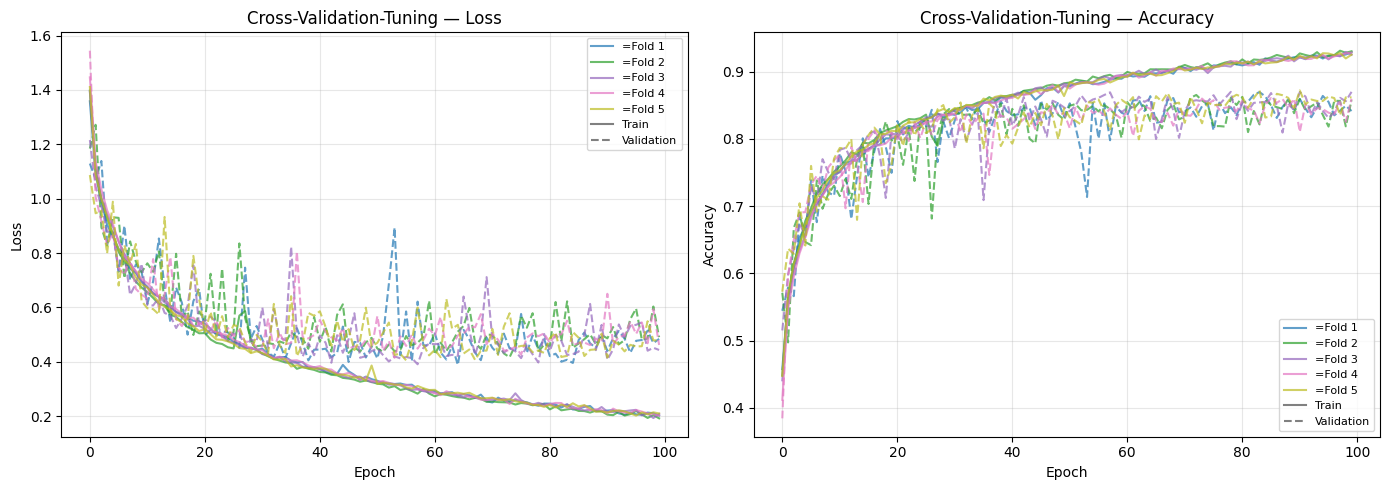

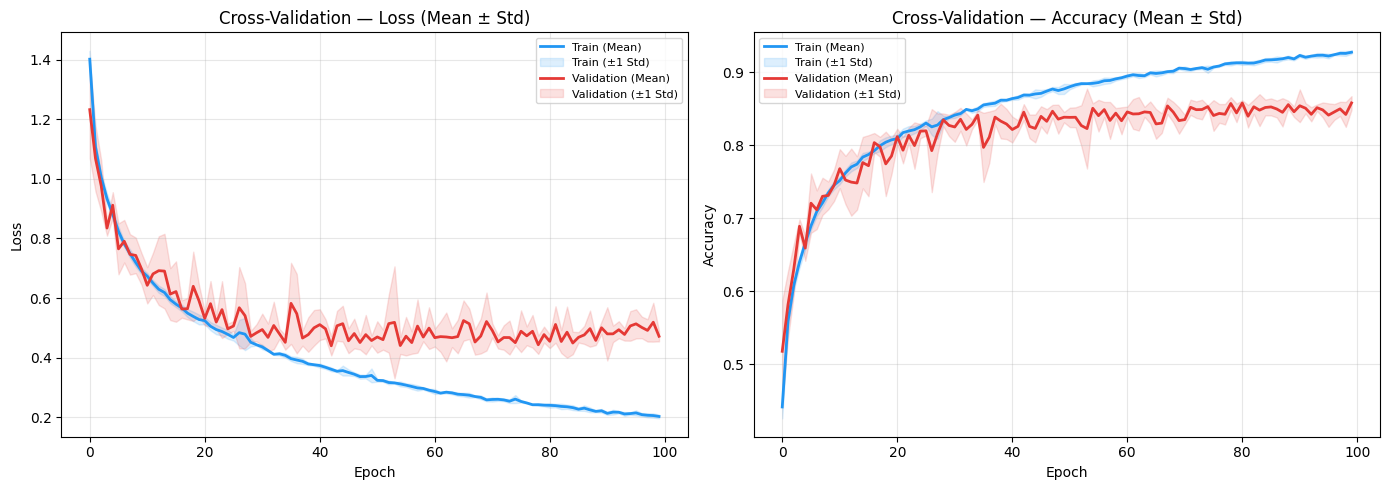

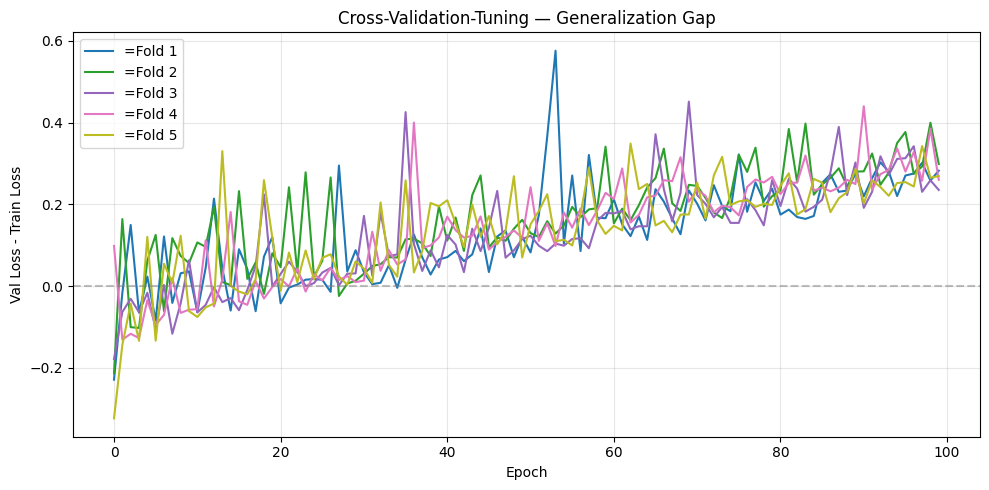

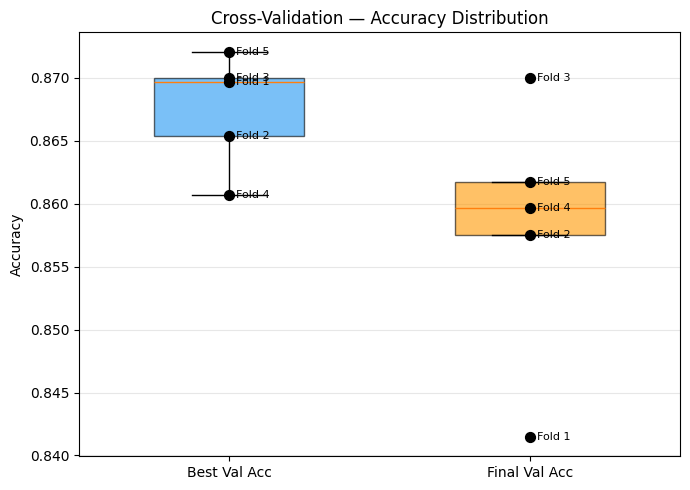

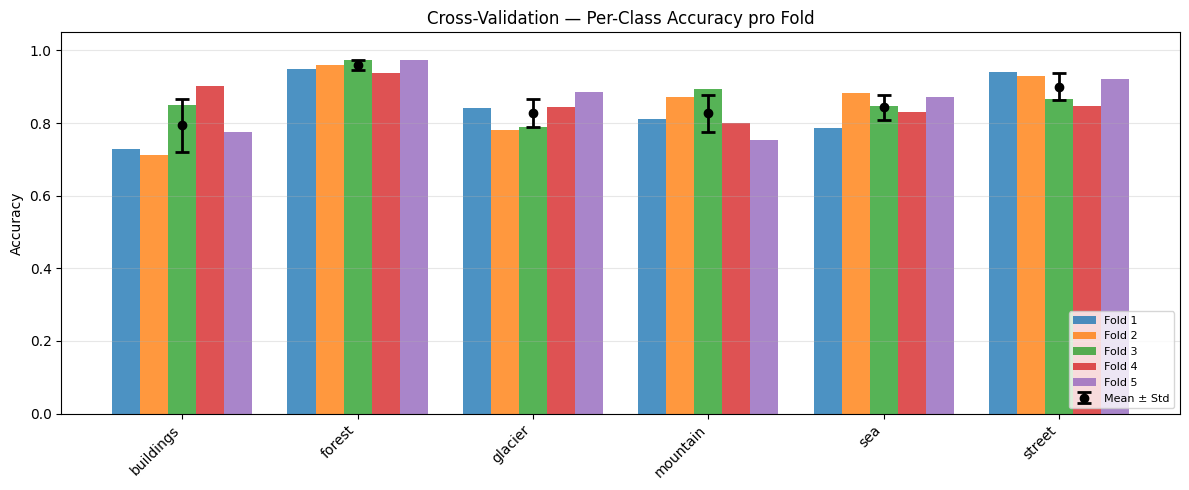

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
train_acc,▁▂▃▃▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▆▅▅▅▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▃▁▄▄▅▆▅▅▆▇▇▇▄▅▄▆▇▆▇▆▇▇▅▇█▆█▇▇▆▇▇▇█▆▇█▇▇█
val_loss,█▆▅▆▃▂▃▆▂▃▂▂▂▁▁▃▃▂▃▂▂▂▁▁▃▂▁▁▂▁▁▁▂▂▁▂▁▁▁▂
epoch,99
train_acc,0.92528
train_loss,0.20976
val_acc,0.86172
val_loss,0.47889


cv/mean_best_acc,▁
cv/mean_final_acc,▁
cv/std_best_acc,▁
cv/std_final_acc,▁
cv/mean_best_acc,0.86754
cv/mean_final_acc,0.85806
cv/std_best_acc,0.00405
cv/std_final_acc,0.00931


In [27]:
# Cross-Validation Ergebnisse zusammenfassen
best_accs = [r["best_val_acc"] for r in fold_results]
final_accs = [r["final_val_acc"] for r in fold_results]

print("Cross-Validation Ergebnisse:")
print(f"{'Fold':>6} | {'Best Val Acc':>12} | {'Final Val Acc':>13}")
print("-" * 40)
for r in fold_results:
    print(f"{r['fold']:>6} | {r['best_val_acc']:>12.4f} | {r['final_val_acc']:>13.4f}")
print("-" * 40)
print(f"{'Mean':>6} | {np.mean(best_accs):>12.4f} | {np.mean(final_accs):>13.4f}")
print(f"{'Std':>6} | {np.std(best_accs):>12.4f} | {np.std(final_accs):>13.4f}")

print(
    f"\nStatistischer Fehler (Best Val Acc): {np.mean(best_accs):.4f} +/- {np.std(best_accs):.4f}"
)
print(f"Hyperparameter: lr={best_lr}, batch_size={best_bs}")

# 1. Train + Val Lernkurven pro Fold (solid=Train, gestrichelt=Validation)
fold_histories = {f"Fold {r['fold']}": r["history"] for r in fold_results}
fig_folds = plot_hp_comparison(fold_histories, hp_name="", hp_label="Cross-Validation")

# 2. Mean ± Std Band
fig_band = plot_cv_mean_std_band(fold_results, title_prefix="Cross-Validation")

# 3. Generalization Gap pro Fold
fig_gap = plot_hp_gap_comparison(
    fold_histories, hp_name="", hp_label="Cross-Validation"
)

# 4. Box-Plot der CV-Ergebnisse
fig_box = plot_cv_boxplot(
    fold_results, title="Cross-Validation — Accuracy Distribution"
)

# 5. Per-Class Accuracy pro Fold
fig_per_class = plot_cv_per_class_accuracy(
    fold_predictions,
    CLASS_NAMES,
    title="Cross-Validation — Per-Class Accuracy pro Fold",
)

# CV-Zusammenfassung an W&B loggen
run = wandb.init(
    project="del-mini-challenge",
    name="cv-summary",
    config={
        "experiment": "cross-validation-summary",
        "k_folds": K_FOLDS,
        "lr": best_lr,
        "batch_size": best_bs,
    },
    reinit=True,
)
wandb.log(
    {
        "cv/fold_learning_curves": wandb.Image(fig_folds),
        "cv/mean_std_band": wandb.Image(fig_band),
        "cv/generalization_gap": wandb.Image(fig_gap),
        "cv/boxplot": wandb.Image(fig_box),
        "cv/per_class_accuracy": wandb.Image(fig_per_class),
        "cv/mean_best_acc": np.mean(best_accs),
        "cv/std_best_acc": np.std(best_accs),
        "cv/mean_final_acc": np.mean(final_accs),
        "cv/std_final_acc": np.std(final_accs),
    }
)
for fig in [fig_folds, fig_band, fig_gap, fig_box, fig_per_class]:
    plt.close(fig)
wandb.finish()

### TODO: Standart fehler anzeigen nicht die Standart abweichung. Der einte wert ist anscheinend noch durch anzahl folds gerechnet -> Anschauen was standart fehler vs standart abweichung genau ist

<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-Cross-validation-Report--VmlldzoxNjYwMTgzNg" style="border:none;height:1024px;width:100%">

# Phase 2: Hyperparameter Tuning

In dieser Phase werden 11 Hypothesen aus sieben Themengruppen untersucht: Modellkomplexitaet (Tiefe, Breite), Conv Layer Settings (Kernel Size, Pooling), Regularisierung (Dropout, Data Augmentation, Weight Decay), BatchNorm, Gewichts-Initialisierung, Adam Optimizer und Transfer Learning.

## Methodik

**Fixe Phase 2 Baseline als Referenz.** Statt pro Hypothese zweimal zu trainieren, wird einmal ein `phase2-baseline` Run mit dem BaseCNN und den besten Hyperparametern aus Stage 1 (lr=0.05, bs=64) trainiert. Alle folgenden Hypothesen werden gegen diesen einen Run verglichen. Das spart Rechenzeit und die Vergleiche sind deterministisch unter identischen Bedingungen.

**50 Epochen pro Experiment.** Aus Stage 1 wissen wir, dass die Val Accuracy beim Basismodell bereits ab ca. Epoche 30 auf einem Plateau zwischen 83 und 86 Prozent liegt und danach hauptsaechlich der Generalization Gap weiter waechst. 50 Epochen reichen also aus, um Peak Accuracy, Konvergenzverhalten und Overfitting-Trend zu beobachten. Laengeres Training wuerde den Vergleich nicht informativer machen, sondern nur Ressourcen binden. Ausnahmen (z.B. Transfer Learning mit weniger Epochen) werden pro Hypothese begruendet.

**Data Augmentation.** Die Stage 1 Pipeline enthaelt bereits `RandomResizedCrop` und `RandomHorizontalFlip`. Die Phase 2 Baseline uebernimmt diese Pipeline unveraendert. H6 (Data Augmentation) untersucht entsprechend, wie stark die Performance einbricht, wenn Augmentation entfernt wird, bzw. was zusaetzliche Augmentations (ColorJitter, RandomRotation) bringen.

## Ablauf pro Hypothese

1. **Hypothese** mit theoretischer Begruendung und Kursreferenz.
2. **Experiment** mit klar definierter Aenderung, alle anderen Hyperparameter konstant.
3. **Analyse und Reflexion** mit Beobachtung, Interpretation und Abgleich mit der Hypothese.

Am Schluss wird das beste Modell aus der Kombination der erfolgversprechenden Techniken gebaut.


## Phase 2 Baseline

Referenz-Run fuer alle Hypothesen. BaseCNN, lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum, keine Regularisierung. W&B Run Name: `phase2-baseline`.


In [28]:
# Phase 2 Baseline: wird einmal trainiert und als Referenz fuer alle Hypothesen verwendet.
PHASE2_EPOCHS = 50

run = wandb.init(
    project="del-mini-challenge",
    name="phase2-baseline",
    config={
        "architecture": "BaseCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "phase2-baseline",
    },
    reinit=True,
)

model_phase2_base = BaseCNN(NUM_CLASSES).to(device)
optimizer_phase2_base = optim.SGD(model_phase2_base.parameters(), lr=best_lr)

history_phase2_base = train_model(
    model_phase2_base,
    train_loader,
    val_loader,
    criterion,
    optimizer_phase2_base,
    device,
    epochs=PHASE2_EPOCHS,
)

results_phase2_base = evaluate_model(
    model_phase2_base,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_base = max(history_phase2_base["val_acc"])
print(f"\nPhase 2 Baseline Peak Val Accuracy: {peak_val_acc_base:.4f}")
wandb.finish()

Epoch   0 | Train Loss: 1.4719  Acc: 0.4006 | Val Loss: 1.1479  Acc: 0.5294
Epoch   1 | Train Loss: 1.1412  Acc: 0.5399 | Val Loss: 1.0969  Acc: 0.5148
Epoch   2 | Train Loss: 1.0323  Acc: 0.5860 | Val Loss: 0.9600  Acc: 0.6110
Epoch   3 | Train Loss: 0.9539  Acc: 0.6266 | Val Loss: 0.8530  Acc: 0.6772
Epoch   4 | Train Loss: 0.8875  Acc: 0.6605 | Val Loss: 0.8994  Acc: 0.6655
Epoch   5 | Train Loss: 0.8226  Acc: 0.6865 | Val Loss: 0.9530  Acc: 0.6441
Epoch   6 | Train Loss: 0.7887  Acc: 0.7071 | Val Loss: 0.6974  Acc: 0.7663
Epoch   7 | Train Loss: 0.7403  Acc: 0.7241 | Val Loss: 0.6841  Acc: 0.7531
Epoch   8 | Train Loss: 0.7124  Acc: 0.7356 | Val Loss: 0.7114  Acc: 0.7300
Epoch   9 | Train Loss: 0.6957  Acc: 0.7416 | Val Loss: 0.7287  Acc: 0.7289
Epoch  10 | Train Loss: 0.6746  Acc: 0.7550 | Val Loss: 0.6143  Acc: 0.7905
Epoch  11 | Train Loss: 0.6398  Acc: 0.7648 | Val Loss: 0.6693  Acc: 0.7592
Epoch  12 | Train Loss: 0.6277  Acc: 0.7667 | Val Loss: 0.6629  Acc: 0.7617
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▆▅▅▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
val_acc,▁▁▃▄▄▆▆▅▇▆▇▄▇▇▇▇▇▇▇▇█▇▇▆▇▇▇██▇▇▇▇▆███▇██
val_loss,█▇▆▅▆▄▃▄▄▃▃▃▆▂▃▂▂▂▂▂▃▁▂▂▅▂▂▂▂▁▃▂▂▃▁▁▂▂▂▂
epoch,49
eval/accuracy,0.83648
train_acc,0.87218
train_loss,0.33858
val_acc,0.83648


## Hypothese 1: Modelltiefe

**Hypothesen:**

1. Ein tieferes CNN mit vier Conv Blöcken statt drei lernt eine reichere Feature Hierarchie und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Da mehr Parameter dazukommen und ohne BatchNorm trainiert wird, entsteht gleichzeitig ein grösserer Generalization Gap.
3. In den ersten Epochen ist mit einem instabileren Trainingsverlauf zu rechnen, weil Gradienten durch mehr Schichten propagieren müssen.

**Begründung:** CNNs lernen hierarchisch. Untere Schichten erkennen Kanten und Texturen, mittlere Schichten Formen, tiefere Schichten ganze Objektteile. Auf den Intel Image Scenes mit Gebäuden, Strassen, Wald, Gletschern, Bergen und Meer sollten gerade die objekthaften Klassen von einer tieferen Hierarchie profitieren. Das Risiko liegt im Optimierer. Bei SGD ohne Momentum und ohne BatchNorm können Gradienten in tieferen Schichten verschwinden oder instabil werden.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`, `05-02-MLP-vs-CNN.pdf`

### Experiment

`DeepCNN`: vier Conv-Bloecke (16 → 32 → 64 → 128 Filter, 3x3 Kernel, MaxPool(2) nach jedem Block). FC-Teil unveraendert. Training mit identischen Bedingungen wie Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen).


In [29]:
class DeepCNN(nn.Module):
    """Vier Conv-Bloecke (16 -> 32 -> 64 -> 128) statt drei. FC-Teil unveraendert."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 16  # 4x MaxPool(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
deep_params = sum(p.numel() for p in DeepCNN(NUM_CLASSES).parameters())
print(f"Baseline (3 Bloecke): {base_params:,} Parameter")
print(
    f"DeepCNN  (4 Bloecke): {deep_params:,} Parameter ({(deep_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h1-depth-4blocks",
    config={
        "architecture": "DeepCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h1-depth",
        "hypothesis": "Mehr Tiefe -> hoehere Val Accuracy, groesserer Gap",
    },
    reinit=True,
)

model_h1 = DeepCNN(NUM_CLASSES).to(device)
optimizer_h1 = optim.SGD(model_h1.parameters(), lr=best_lr)

history_h1 = train_model(
    model_h1,
    train_loader,
    val_loader,
    criterion,
    optimizer_h1,
    device,
    epochs=PHASE2_EPOCHS,
)

results_h1 = evaluate_model(
    model_h1,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h1 = max(history_h1["val_acc"])
print(f"\nH1 DeepCNN Peak Val Accuracy: {peak_val_acc_h1:.4f}")
print(f"Baseline Peak Val Accuracy:   {peak_val_acc_base:.4f}")
print(
    f"Differenz:                    {(peak_val_acc_h1 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)
wandb.finish()

Baseline (3 Bloecke): 548,774 Parameter
DeepCNN  (4 Bloecke): 360,486 Parameter (-34.3%)


Epoch   0 | Train Loss: 1.5396  Acc: 0.3781 | Val Loss: 1.1592  Acc: 0.5554
Epoch   1 | Train Loss: 1.1931  Acc: 0.5227 | Val Loss: 1.2061  Acc: 0.5208
Epoch   2 | Train Loss: 1.0665  Acc: 0.5710 | Val Loss: 0.9961  Acc: 0.5892
Epoch   3 | Train Loss: 1.0014  Acc: 0.6070 | Val Loss: 1.0254  Acc: 0.5625
Epoch   4 | Train Loss: 0.9474  Acc: 0.6278 | Val Loss: 0.8531  Acc: 0.6808
Epoch   5 | Train Loss: 0.9029  Acc: 0.6513 | Val Loss: 0.8197  Acc: 0.6744
Epoch   6 | Train Loss: 0.8443  Acc: 0.6780 | Val Loss: 0.8312  Acc: 0.6965
Epoch   7 | Train Loss: 0.8280  Acc: 0.6874 | Val Loss: 0.7443  Acc: 0.7232
Epoch   8 | Train Loss: 0.7786  Acc: 0.7124 | Val Loss: 0.6822  Acc: 0.7563
Epoch   9 | Train Loss: 0.7516  Acc: 0.7199 | Val Loss: 0.7759  Acc: 0.7157
Epoch  10 | Train Loss: 0.7292  Acc: 0.7321 | Val Loss: 0.6440  Acc: 0.7777
Epoch  11 | Train Loss: 0.7065  Acc: 0.7431 | Val Loss: 0.8176  Acc: 0.6990
Epoch  12 | Train Loss: 0.6775  Acc: 0.7544 | Val Loss: 0.7078  Acc: 0.7403
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▂▁▂▂▄▅▅▆▅▆▆▆▇▆▆▇▇▇▇▇█▇█▇▇█▆█▇█▆█████▇██▇
val_loss,██▆▆▅▅▄▃▃▅▃▂▃▃▂▂▂▂▂▂▁▂▂▂▃▃▁▁▁▁▃▁▁▁▁▁▂▁▁▂
epoch,49
eval/accuracy,0.81261
train_acc,0.87771
train_loss,0.33379
val_acc,0.81261


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H1-Modelltiefe--VmlldzoxNjYxNDYzMQ" style="border:none;height:1024px;width:100%">

## Hypothese 2: Modellbreite

**Hypothesen:**

1. Ein breiteres CNN mit doppelt so vielen Filtern pro Block lernt vielfältigere Muster pro Schicht und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Da die Parameterzahl stark ansteigt und weiterhin ohne BatchNorm und ohne Regularisierung trainiert wird, ist mit einem grösseren Generalization Gap zu rechnen.
3. Da die Anzahl Schichten gleich bleibt und die Filter voneinander unabhängig lernen, ist das Training nicht merklich instabiler als bei der Baseline.

**Begründung:** Die Anzahl Filter pro Conv Schicht bestimmt, wie viele unterschiedliche Merkmale auf derselben Abstraktionsebene parallel erkannt werden können. Mit doppelt so vielen Filtern kann das Netz mehr Kantenorientierungen, Texturen und Farbmuster gleichzeitig abdecken. Bei den sechs Szenenklassen helfen reichere Texturen vor allem bei ähnlich aussehenden Naturklassen wie `glacier`, `mountain` und `sea`, die von der Baseline oft verwechselt werden. Das Risiko liegt in der deutlich grösseren Parameterzahl, die ohne Regularisierung schneller auswendig lernen kann.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`WideCNN`: drei Conv Blöcke wie in der Baseline, aber mit doppelter Filteranzahl (32 → 64 → 128 statt 16 → 32 → 64). Kernel Size 3x3, MaxPool(2) nach jedem Block, FC Teil unverändert. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [30]:
class WideCNN(nn.Module):
    """Drei Conv Blöcke wie BaseCNN, aber mit doppelter Filteranzahl (32 -> 64 -> 128)."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8  # 3x MaxPool(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
wide_params = sum(p.numel() for p in WideCNN(NUM_CLASSES).parameters())
print(f"Baseline (Filter 16/32/64):  {base_params:,} Parameter")
print(
    f"WideCNN  (Filter 32/64/128): {wide_params:,} Parameter ({(wide_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h2-width-2x",
    config={
        "architecture": "WideCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h2-width",
        "hypothesis": "Mehr Filter pro Block -> hoehere Val Accuracy, groesserer Gap",
    },
    reinit=True,
)

model_h2 = WideCNN(NUM_CLASSES).to(device)
optimizer_h2 = optim.SGD(model_h2.parameters(), lr=best_lr)

history_h2 = train_model(
    model_h2,
    train_loader,
    val_loader,
    criterion,
    optimizer_h2,
    device,
    epochs=PHASE2_EPOCHS,
)

results_h2 = evaluate_model(
    model_h2,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h2 = max(history_h2["val_acc"])
print(f"\nH2 WideCNN Peak Val Accuracy: {peak_val_acc_h2:.4f}")
print(f"Baseline Peak Val Accuracy:   {peak_val_acc_base:.4f}")
print(
    f"Differenz:                    {(peak_val_acc_h2 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline (Filter 16/32/64):  548,774 Parameter
WideCNN  (Filter 32/64/128): 1,142,726 Parameter (+108.2%)


Epoch   0 | Train Loss: 1.3558  Acc: 0.4662 | Val Loss: 1.2562  Acc: 0.5159
Epoch   1 | Train Loss: 1.0665  Acc: 0.5801 | Val Loss: 0.9267  Acc: 0.6459
Epoch   2 | Train Loss: 0.9468  Acc: 0.6436 | Val Loss: 1.3811  Acc: 0.5344
Epoch   3 | Train Loss: 0.8902  Acc: 0.6639 | Val Loss: 0.7499  Acc: 0.7207
Epoch   4 | Train Loss: 0.8240  Acc: 0.6923 | Val Loss: 0.7376  Acc: 0.7353
Epoch   5 | Train Loss: 0.7807  Acc: 0.7113 | Val Loss: 0.7555  Acc: 0.7225
Epoch   6 | Train Loss: 0.7365  Acc: 0.7281 | Val Loss: 0.7076  Acc: 0.7496
Epoch   7 | Train Loss: 0.6936  Acc: 0.7451 | Val Loss: 0.6717  Acc: 0.7620
Epoch   8 | Train Loss: 0.6681  Acc: 0.7544 | Val Loss: 0.7082  Acc: 0.7403
Epoch   9 | Train Loss: 0.6326  Acc: 0.7700 | Val Loss: 0.6500  Acc: 0.7766
Epoch  10 | Train Loss: 0.6184  Acc: 0.7747 | Val Loss: 1.0732  Acc: 0.6106
Epoch  11 | Train Loss: 0.6023  Acc: 0.7828 | Val Loss: 0.6626  Acc: 0.7592
Epoch  12 | Train Loss: 0.5743  Acc: 0.7879 | Val Loss: 0.5921  Acc: 0.7866
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▁▅▅▆▆▆▆▃▆▇▇▇▇▇▇▇▇█▇▇▇█▇▆▇█▆█▇█▇██▇█▇█▇
val_loss,▇▅█▃▃▃▃▃▃▆▂▂▂▂▂▄▂▂▂▂▂▁▁▁▂▂▁▃▁▁▂▁▂▁▁▂▁▂▁▂
epoch,49
eval/accuracy,0.82864
train_acc,0.9022
train_loss,0.26882
val_acc,0.82864


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H2-Modellbreite--VmlldzoxNjYxNTY4Nw" style="border:none;height:1024px;width:100%">

## Hypothese 3: Kernel Size

**Hypothesen:**

1. Ein grösserer Conv Kernel von 5x5 erfasst pro Schicht mehr räumlichen Kontext als ein 3x3 Kernel und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Da mit 5x5 deutlich mehr Gewichte pro Conv Schicht dazukommen, wächst die Parameterzahl moderat, und der Generalization Gap kann leicht zunehmen.
3. Die Trainingsstabilität bleibt vergleichbar mit der Baseline, weil die Netztiefe identisch bleibt und nur die Filtergrösse verändert wird.

**Begründung:** Die Kernelgrösse bestimmt, wie viele benachbarte Pixel pro Filter direkt zusammengefasst werden. Mit 5x5 sieht jeder Filter in einem einzigen Schritt eine grössere Umgebung, was das Receptive Field pro Schicht vergrössert. Bei nur drei Conv Blöcken kann das ein Vorteil sein, weil die Baseline mit 3x3 Kernels erst nach mehreren Schichten genug räumlichen Kontext aggregiert. Für Szenenbilder mit grossräumigen Strukturen wie Bergketten, Wolken oder Waldflächen ist mehr Kontext pro Schicht plausibel hilfreich. Der Nachteil liegt in der Parameterzahl, da ein 5x5 Kernel 25 Gewichte pro Filter benötigt statt 9 bei 3x3.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`LargeKernelCNN`: drei Conv Blöcke wie in der Baseline und gleiche Filteranzahl (16 → 32 → 64), aber mit 5x5 Kernel statt 3x3. Padding wird auf 2 erhöht, damit die Feature Map Grösse pro Block gleich bleibt. FC Teil unverändert. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [32]:
class LargeKernelCNN(nn.Module):
    """Drei Conv Blöcke wie BaseCNN, aber mit 5x5 Kernel statt 3x3 (padding=2)."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8  # 3x MaxPool(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
lk_params = sum(p.numel() for p in LargeKernelCNN(NUM_CLASSES).parameters())
print(f"Baseline (3x3 Kernel):       {base_params:,} Parameter")
print(
    f"LargeKernelCNN (5x5 Kernel): {lk_params:,} Parameter ({(lk_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h3-kernel-5x5",
    config={
        "architecture": "LargeKernelCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h3-kernel-size",
        "hypothesis": "5x5 Kernel -> mehr Kontext pro Schicht -> hoehere Val Accuracy",
    },
    reinit=True,
)

model_h3 = LargeKernelCNN(NUM_CLASSES).to(device)
optimizer_h3 = optim.SGD(model_h3.parameters(), lr=best_lr)

history_h3 = train_model(
    model_h3,
    train_loader,
    val_loader,
    criterion,
    optimizer_h3,
    device,
    epochs=PHASE2_EPOCHS,
)

results_h3 = evaluate_model(
    model_h3,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h3 = max(history_h3["val_acc"])
print(f"\nH3 LargeKernelCNN Peak Val Accuracy: {peak_val_acc_h3:.4f}")
print(f"Baseline Peak Val Accuracy:          {peak_val_acc_base:.4f}")
print(
    f"Differenz:                           {(peak_val_acc_h3 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline (3x3 Kernel):       548,774 Parameter
LargeKernelCNN (5x5 Kernel): 590,502 Parameter (+7.6%)


Epoch   0 | Train Loss: 1.4276  Acc: 0.4203 | Val Loss: 1.1050  Acc: 0.5661
Epoch   1 | Train Loss: 1.3457  Acc: 0.4712 | Val Loss: 1.2077  Acc: 0.4831
Epoch   2 | Train Loss: 1.0433  Acc: 0.5894 | Val Loss: 0.9076  Acc: 0.6434
Epoch   3 | Train Loss: 0.9697  Acc: 0.6254 | Val Loss: 0.8966  Acc: 0.6569
Epoch   4 | Train Loss: 0.9049  Acc: 0.6516 | Val Loss: 0.8236  Acc: 0.7057
Epoch   5 | Train Loss: 0.8490  Acc: 0.6788 | Val Loss: 0.7343  Acc: 0.7292
Epoch   6 | Train Loss: 0.8046  Acc: 0.7001 | Val Loss: 0.7006  Acc: 0.7517
Epoch   7 | Train Loss: 0.7586  Acc: 0.7193 | Val Loss: 0.7560  Acc: 0.7193
Epoch   8 | Train Loss: 0.7264  Acc: 0.7269 | Val Loss: 0.6761  Acc: 0.7681
Epoch   9 | Train Loss: 0.6948  Acc: 0.7438 | Val Loss: 0.6653  Acc: 0.7642
Epoch  10 | Train Loss: 0.6660  Acc: 0.7543 | Val Loss: 0.6707  Acc: 0.7585
Epoch  11 | Train Loss: 0.6444  Acc: 0.7654 | Val Loss: 0.7599  Acc: 0.7289
Epoch  12 | Train Loss: 0.6247  Acc: 0.7716 | Val Loss: 0.6617  Acc: 0.7602
Epoch  13 | 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▂▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▃▁▄▄▅▆▅▆▆▆▇▇▅▇▇▇▇▇▇███▇▇███▆██▆███████▇█
val_loss,▇█▅▅▄▃▄▃▃▃▃▃▂▂▂▂▂▂▁▄▂▁▁▂▁▁▁▄▁▁▃▁▁▂▁▁▁▁▃▁
epoch,49
eval/accuracy,0.83506
train_acc,0.88474
train_loss,0.31541
val_acc,0.83506


<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H3-Kernal-Size--VmlldzoxNjYyNDkzNg" style="border:none;height:1024px;width:100%">

## Hypothese 4: Pooling Strategie

**Hypothesen:**

1. Ein Netz mit AvgPool statt MaxPool erreicht eine tiefere Val Accuracy als die Baseline, weil MaxPool die markantesten lokalen Merkmale gezielt durchlässt, während AvgPool sie glättet.
2. Der Generalization Gap fällt bei AvgPool tendenziell kleiner aus, weil die Durchschnittsbildung eine weichere Repräsentation erzeugt und damit einen milden Regularisierungseffekt hat.
3. Die Trainingsstabilität bleibt vergleichbar mit der Baseline, weil sich weder die Netztiefe, die Breite noch die Parameterzahl ändern.

**Begründung:** MaxPool und AvgPool sind die beiden klassischen Downsampling Operationen in CNNs. MaxPool wählt pro Fenster die stärkste Aktivierung und hebt dadurch scharfe Merkmale wie Kanten und Ecken hervor. AvgPool bildet den Durchschnitt und erzeugt eine glattere, verrauschtere Zusammenfassung. Bei Szenenbildern mit ausgeprägten Strukturen wie Gebäudekanten, Strassenmarkierungen oder Berggraten sollte MaxPool im Vorteil sein. AvgPool könnte umgekehrt bei homogen texturierten Klassen wie Meer oder Wald eine rauschresistentere Repräsentation liefern. Da die Parameterzahl identisch bleibt, ist dies eine reine Ablation auf der Pooling Operation.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `05-02-MLP-vs-CNN.pdf`

### Experiment

`AvgPoolCNN`: identisch zur Baseline (drei Conv Blöcke, 16 → 32 → 64 Filter, 3x3 Kernel), aber mit `AvgPool2d(2)` statt `MaxPool2d(2)` nach jedem Block. FC Teil unverändert. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [ ]:
class AvgPoolCNN(nn.Module):
    """Baseline Architektur mit AvgPool2d statt MaxPool2d."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2),
        )
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich (sollte identisch sein)
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
avg_params = sum(p.numel() for p in AvgPoolCNN(NUM_CLASSES).parameters())
print(f"Baseline (MaxPool): {base_params:,} Parameter")
print(
    f"AvgPoolCNN:         {avg_params:,} Parameter ({(avg_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h4-avgpool",
    config={
        "architecture": "AvgPoolCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "experiment": "h4-pooling",
        "hypothesis": "AvgPool statt MaxPool -> tiefere Val Accuracy, kleinerer Gap",
    },
    reinit=True,
)

model_h4 = AvgPoolCNN(NUM_CLASSES).to(device)
optimizer_h4 = optim.SGD(model_h4.parameters(), lr=best_lr)

history_h4 = train_model(
    model_h4,
    train_loader,
    val_loader,
    criterion,
    optimizer_h4,
    device,
    epochs=PHASE2_EPOCHS,
)

results_h4 = evaluate_model(
    model_h4,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h4 = max(history_h4["val_acc"])
print(f"\nH4 AvgPoolCNN Peak Val Accuracy: {peak_val_acc_h4:.4f}")
print(f"Baseline Peak Val Accuracy:      {peak_val_acc_base:.4f}")
print(
    f"Differenz:                       {(peak_val_acc_h4 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

<iframe src="https://wandb.ai/mannaluca02-fachhochschule-nordwestschweiz-fhnw/del-mini-challenge/reports/DEL-H4-Avg-Pooling--VmlldzoxNjYyNjEwNw" style="border:none;height:1024px;width:100%">

## Hypothese 5: Dropout

**Hypothesen:**

1. Ein Netz mit Dropout im FC Teil reduziert Overfitting und erreicht dadurch eine höhere Val Accuracy als die Baseline.
2. Der Generalization Gap fällt deutlich kleiner aus, weil Dropout während des Trainings zufällig Aktivierungen abschaltet und das Netz zwingt, redundante Repräsentationen zu lernen.
3. Die Konvergenz verläuft etwas langsamer und verrauschter, weil pro Batch nur ein Teil der Neuronen aktiv ist und der Optimierer dadurch verrauschtere Gradientenschätzungen bekommt.

**Begründung:** Dropout ist die klassische Regularisierungstechnik in CNNs. Mit einer Wahrscheinlichkeit p wird jedes Neuron im FC Teil während des Trainings temporär auf Null gesetzt. Das zwingt das Netz, sich nicht auf einzelne starke Features zu verlassen, sondern verteilte und robuste Repräsentationen zu lernen. Bei der Inferenz sind alle Neuronen aktiv und die Ausgaben werden entsprechend skaliert. Da die Baseline ohne jegliche Regularisierung trainiert wird und in den bisherigen Runs ein moderater Generalization Gap mit Val Loss Spikes bis etwa 0.4 sichtbar ist, sollte Dropout genau hier ansetzen. Ein Standardwert von p=0.5 im FC Teil ist der Ausgangspunkt.

**Kursreferenz:** `deepdive_pytorch_cnn.pdf`, `imagenet_architectures.pdf`

### Experiment

`DropoutCNN`: identisch zur Baseline (drei Conv Blöcke, 16 → 32 → 64 Filter, 3x3 Kernel, MaxPool(2)), aber mit einem zusätzlichen `nn.Dropout(p=0.5)` zwischen den beiden FC Schichten. Training unter denselben Bedingungen wie die Phase 2 Baseline (lr=0.05, bs=64, 50 Epochen, SGD ohne Momentum).

In [35]:
class DropoutCNN(nn.Module):
    """Baseline Architektur mit zusätzlichem Dropout (p=0.5) im FC Teil."""

    def __init__(self, num_classes=6, img_size=IMG_SIZE, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: img_size -> img_size/2
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: img_size/2 -> img_size/4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: img_size/4 -> img_size/8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        feat_size = img_size // 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * feat_size * feat_size, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Parameter-Vergleich (sollte identisch sein, Dropout hat keine Gewichte)
dropout_p = 0.5
base_params = sum(p.numel() for p in BaseCNN(NUM_CLASSES).parameters())
drop_params = sum(
    p.numel() for p in DropoutCNN(NUM_CLASSES, dropout_p=dropout_p).parameters()
)
print(f"Baseline:       {base_params:,} Parameter")
print(
    f"DropoutCNN:     {drop_params:,} Parameter ({(drop_params/base_params - 1)*100:+.1f}%)"
)

run = wandb.init(
    project="del-mini-challenge",
    name="h5-dropout-0.5",
    config={
        "architecture": "DropoutCNN",
        "optimizer": "SGD",
        "lr": best_lr,
        "momentum": 0.0,
        "batch_size": best_bs,
        "epochs": PHASE2_EPOCHS,
        "dropout_p": dropout_p,
        "experiment": "h5-dropout",
        "hypothesis": "Dropout 0.5 im FC -> kleinerer Gap, hoehere Val Accuracy",
    },
    reinit=True,
)

model_h5 = DropoutCNN(NUM_CLASSES, dropout_p=dropout_p).to(device)
optimizer_h5 = optim.SGD(model_h5.parameters(), lr=best_lr)

history_h5 = train_model(
    model_h5,
    train_loader,
    val_loader,
    criterion,
    optimizer_h5,
    device,
    epochs=PHASE2_EPOCHS,
)

results_h5 = evaluate_model(
    model_h5,
    val_loader,
    CLASS_NAMES,
    device,
    channel_mean,
    channel_std,
)

peak_val_acc_h5 = max(history_h5["val_acc"])
print(f"\nH5 DropoutCNN Peak Val Accuracy: {peak_val_acc_h5:.4f}")
print(f"Baseline Peak Val Accuracy:      {peak_val_acc_base:.4f}")
print(
    f"Differenz:                       {(peak_val_acc_h5 - peak_val_acc_base)*100:+.2f} Prozentpunkte"
)

run.finish()

Baseline:       548,774 Parameter
DropoutCNN:     548,774 Parameter (+0.0%)


Epoch   0 | Train Loss: 1.4450  Acc: 0.4154 | Val Loss: 1.1721  Acc: 0.5087
Epoch   1 | Train Loss: 1.1612  Acc: 0.5327 | Val Loss: 1.0099  Acc: 0.5935
Epoch   2 | Train Loss: 1.0634  Acc: 0.5879 | Val Loss: 0.9267  Acc: 0.6548
Epoch   3 | Train Loss: 0.9969  Acc: 0.6120 | Val Loss: 0.8765  Acc: 0.6701
Epoch   4 | Train Loss: 0.9566  Acc: 0.6370 | Val Loss: 0.8572  Acc: 0.6869
Epoch   5 | Train Loss: 0.8918  Acc: 0.6663 | Val Loss: 0.7770  Acc: 0.7271
Epoch   6 | Train Loss: 0.8450  Acc: 0.6885 | Val Loss: 0.7005  Acc: 0.7506
Epoch   7 | Train Loss: 0.8042  Acc: 0.7057 | Val Loss: 0.7601  Acc: 0.7257
Epoch   8 | Train Loss: 0.7782  Acc: 0.7217 | Val Loss: 0.7810  Acc: 0.7328
Epoch   9 | Train Loss: 0.7600  Acc: 0.7266 | Val Loss: 0.6756  Acc: 0.7563
Epoch  10 | Train Loss: 0.7280  Acc: 0.7377 | Val Loss: 0.9835  Acc: 0.6551
Epoch  11 | Train Loss: 0.7112  Acc: 0.7424 | Val Loss: 0.6301  Acc: 0.7841
Epoch  12 | Train Loss: 0.6882  Acc: 0.7522 | Val Loss: 0.6048  Acc: 0.7919
Epoch  13 | 

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
eval/accuracy,▁
train_acc,▁▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████████
train_loss,█▆▅▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▄▄▅▆▅▅▆▄▇▇▆▆▇▇▆▇▇▇▇▇▇█▇██▇█▇▆█▇▆██▇█▇█
val_loss,█▆▆▅▅▄▄▄▃▆▃▂▄▃▃▃▂▄▃▂▃▁▂▂▂▁▂▁▂▁▁▄▁▂▃▁▂▁▂▂
epoch,49
eval/accuracy,0.83506
train_acc,0.84404
train_loss,0.4244
val_acc,0.83506


### Analyse und Reflexion

_Nach dem Training ausfüllen. Im W&B Report die Runs `phase2-baseline` und `h5-dropout-0.5` als Vergleich darstellen: Train/Val Loss, Train/Val Accuracy, Generalization Gap._

**Beobachtung:**

- ...

**Abgleich mit Hypothese:**

- ...

**Einordnung:**

- ...